# Superstore Sales Analytics and Profit Prediction

A practical analysis of the Superstore dataset covering data quality checks, sales and profit patterns, customer segmentation, order-line profit prediction, and a lightweight monthly sales forecast.

## Overview and Goals

This notebook analyzes the **Superstore sales dataset (2014–2017)** to support practical retail decisions.

The workflow answers five business questions:

- Which months, regions, categories, and sub-categories drive sales and profit?
- Where do discounts, geography, or product mix create margin pressure?
- Which customers are most valuable or at risk based on RFM segmentation?
- Can we build a reusable baseline model to estimate order-line profit from known order details?
- What does a simple monthly sales forecast suggest for near-term planning?

## Important Scope Note

The main supervised model in this notebook is **profit prediction**, not pure future sales forecasting.

The model predicts **line-item profit after core transaction details are known**. The final forecasting section is included as a lightweight, exploratory sales trend estimate, not as a production-grade forecasting system.

## Config and Imports

In [10]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_SEED = 42
PRIMARY_COLOR = "#4C78A8"
CV_MAX_ROWS = 3000

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)


def rmse_score(y_true, y_pred):
    """Return root mean squared error with broad scikit-learn compatibility."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def find_superstore_csv():
    """Find the Superstore CSV on Kaggle or in a local project layout."""
    candidate_paths = [
        Path("/kaggle/input/superstore-dataset-final/Sample - Superstore.csv"),
        Path("../input/superstore-dataset-final/Sample - Superstore.csv"),
        Path("/kaggle/input/superstore-sales-dataset/Sample - Superstore.csv"),
        Path("../input/superstore-sales-dataset/Sample - Superstore.csv"),
        Path("Sample - Superstore.csv"),
        Path("data/raw/Sample - Superstore.csv"),
        Path("../data/raw/Sample - Superstore.csv"),
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    search_roots = [Path("/kaggle/input"), Path("."), Path("data/raw"), Path("../data/raw")]
    for root in search_roots:
        if root.exists():
            matches = sorted(root.rglob("*Superstore*.csv"))
            if matches:
                return matches[0]

    raise FileNotFoundError(
        "Superstore CSV not found. Place 'Sample - Superstore.csv' in the working directory, "
        "data/raw/, or attach the Kaggle dataset to the notebook."
    )

## Data Loading

In [11]:
DATA_PATH = find_superstore_csv()

df = pd.read_csv(DATA_PATH, encoding="windows-1252")
print(f"Loaded data from: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

Loaded data from: Sample - Superstore.csv
Shape: 9,994 rows × 21 columns


## Initial Data Exploration

In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.000,41.914
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,3,0.000,219.582
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.000,6.871
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.577,5,0.450,-383.031
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.200,2.516


#### an overview of the possible region exist 

In [13]:
print(df['Region'].unique())
#  North region doesn't exist in this data set 

['South' 'West' 'Central' 'East']


#### Display concise summary of DataFrame: data types, non-null counts, and memory usage


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

#### Identify outliers and understand data spread by reviewing min, max, and percentile values


In [15]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,"9,994.000","9,994.000","9,994.000","9,994.000","9,994.000","9,994.000"
mean,"4,997.500","55,190.379",229.858,3.790,0.156,28.657
std,"2,885.164","32,063.693",623.245,2.225,0.206,234.260
min,1.000,"1,040.000",0.444,1.000,0.000,"-6,599.978"
25%,"2,499.250","23,223.000",17.280,2.000,0.000,1.729
50%,"4,997.500","56,430.500",54.490,3.000,0.200,8.666
75%,"7,495.750","90,008.000",209.940,5.000,0.200,29.364
max,"9,994.000","99,301.000","22,638.480",14.000,0.800,"8,399.976"


#### Include categorical columns in summary statistics (frequency, unique counts, top values)


In [16]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,"9,994.000",9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,"9,994.000",9994,9994,9994,9994,9994,"9,994.000","9,994.000","9,994.000","9,994.000"
unique,NaN,5009,1237,1334,4,793,793,3,1,531,49,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,2001,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,"4,997.500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"55,190.379",NaN,NaN,NaN,NaN,NaN,229.858,3.790,0.156,28.657
std,"2,885.164",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"32,063.693",NaN,NaN,NaN,NaN,NaN,623.245,2.225,0.206,234.260
min,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,040.000",NaN,NaN,NaN,NaN,NaN,0.444,1.000,0.000,"-6,599.978"
25%,"2,499.250",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"23,223.000",NaN,NaN,NaN,NaN,NaN,17.280,2.000,0.000,1.729
50%,"4,997.500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"56,430.500",NaN,NaN,NaN,NaN,NaN,54.490,3.000,0.200,8.666
75%,"7,495.750",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"90,008.000",NaN,NaN,NaN,NaN,NaN,209.940,5.000,0.200,29.364


#### NaN (Not a Number) values are automatically excluded from statistical calculations,but when we put include="all" we includes ALL columns (numerical + categorical + object)


In [17]:
df.shape

(9994, 21)

#### return the shape of our dataset 

## Data Cleaning

### Check missing values & duplicates


In [18]:
# Missing values 
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### We quantify missing values per column to plan imputation or safe drops.

In [19]:
# Remove duplicates
df.duplicated().sum()

np.int64(0)

### We remove duplicates to prevent double counting.

### Convert to datetime

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.drop_duplicates(inplace=True)

**Observation :**  
Dans le fichier CSV d'origine, les dates sont des chaînes de caractères (ex: "11/8/2016").  
Sans conversion, on ne peut pas :
- Calculer l'écart entre Ship Date et Order Date
- Extraire le mois ou l'année
- Trier chronologiquement
- Regrouper par mois avec `resample('M')`

La conversion `pd.to_datetime()` transforme ces chaînes en véritables objets temporels, rendant toutes ces opérations possibles.

### We convert Order Date and Ship Date to datetime, unlocking time‑based analysis and lead‑time metrics.

In [21]:
sales_month_by_period  = (df.set_index('Order Date').resample('M')['Sales'].sum().sort_index())
profit_month_by_period = (df.set_index('Order Date').resample('M')['Profit'].sum().sort_index())

**pour analyser ventes par mois, comparaison année par année..**

We resample by calendar month to build two core time series:

- `sales_month_by_period`: total sales per month
- `profit_month_by_period`: total profit per month

These series support trend charts, seasonality checks, and the exploratory forecast at the end.

## 👥 RFM Customer Segmentation

RFM analysis divides customers based on **Recency**, **Frequency**, and **Monetary value** to identify actionable groups such as *Champions*, *Loyal*, *Potential Loyalists*, and *At Risk*.  
This helps businesses target marketing and retention strategies more effectively.

---

### 🧩 Visual Representation
![RFM Customer Segmentation](https://copilot.microsoft.com/th/id/BCO.de0d7aaf-c9e0-48f8-a70f-1cd615b73a23.png)

---

### ✅ Key Insight
Customers with high **Recency**, **Frequency**, and **Monetary** scores are your most valuable — they should be prioritized for loyalty and advocacy programs.


In [22]:
kpis = {}
kpis['total_sales']   = float(df['Sales'].sum())
kpis['total_profit']  = float(df['Profit'].sum())
kpis['avg_ship_days'] = (df['Ship Date'] - df['Order Date']).dt.days.clip(lower=0).mean()

kpis['top_months_sales'] = (sales_month_by_period.sort_values(ascending=False)
                                            .head(5).index.strftime('%Y-%m').tolist())
kpis['highest_region'] = df.groupby('Region')['Sales'].sum().idxmax()
kpis['top_category']   = df.groupby('Category')['Sales'].sum().idxmax()

today = df['Order Date'].max() + pd.Timedelta(days=1)
_rfm = df.groupby('Customer ID').agg(
    Recency  = ('Order Date', lambda x: (today - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary =('Sales', 'sum')
).reset_index()

_rfm['R_Score'] = pd.qcut(_rfm['Recency'], 4, labels=[4,3,2,1])
_rfm['F_Score'] = pd.qcut(_rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
_rfm['M_Score'] = pd.qcut(_rfm['Monetary'], 4, labels=[1,2,3,4])
_rfm[['R_Score','F_Score','M_Score']] = _rfm[['R_Score','F_Score','M_Score']].astype(int)
_rfm['RFM_Sum'] = _rfm[['R_Score','F_Score','M_Score']].sum(axis=1)

def _seg(s):
    if s >= 10: return 'Champions'
    if s >= 8:  return 'Loyal'
    if s >= 6:  return 'Potential'
    return 'At Risk'
_rfm['Segment'] = _rfm['RFM_Sum'].apply(_seg)

rfm_pct = (_rfm['Segment'].value_counts(normalize=True)*100).round(0).astype(int)
for g in ['Champions','Loyal','Potential','At Risk']:
    if g not in rfm_pct: rfm_pct.loc[g] = 0
rfm_pct = rfm_pct[['Champions','Loyal','Potential','At Risk']]

exec_md = f"""
## Executive Summary

- Strong seasonality with **December spikes**; **Top months:** {", ".join(kpis['top_months_sales'])}.
- **{kpis['highest_region']}** leads by sales; **{kpis['top_category']}** is the top category.
- **Avg. shipping time ≈ {kpis['avg_ship_days']:.2f} days**.
- **Total sales:** {kpis['total_sales']:,.2f} · **Total profit:** {kpis['total_profit']:,.2f}.
- **RFM mix:** Champions {rfm_pct['Champions']}% · Loyal {rfm_pct['Loyal']}% · Potential {rfm_pct['Potential']}% · At Risk {rfm_pct['At Risk']}%.
"""
display(Markdown(exec_md))


## Executive Summary

- Strong seasonality with **December spikes**; **Top months:** 2017-11, 2016-12, 2017-09, 2017-12, 2014-09.
- **West** leads by sales; **Technology** is the top category.
- **Avg. shipping time ≈ 3.96 days**.
- **Total sales:** 2,297,200.86 · **Total profit:** 286,397.02.
- **RFM mix:** Champions 24% · Loyal 28% · Potential 23% · At Risk 25%.


### Categorical Coverage

## Exploratory Data Analysis (EDA)

### Correlation Matrix

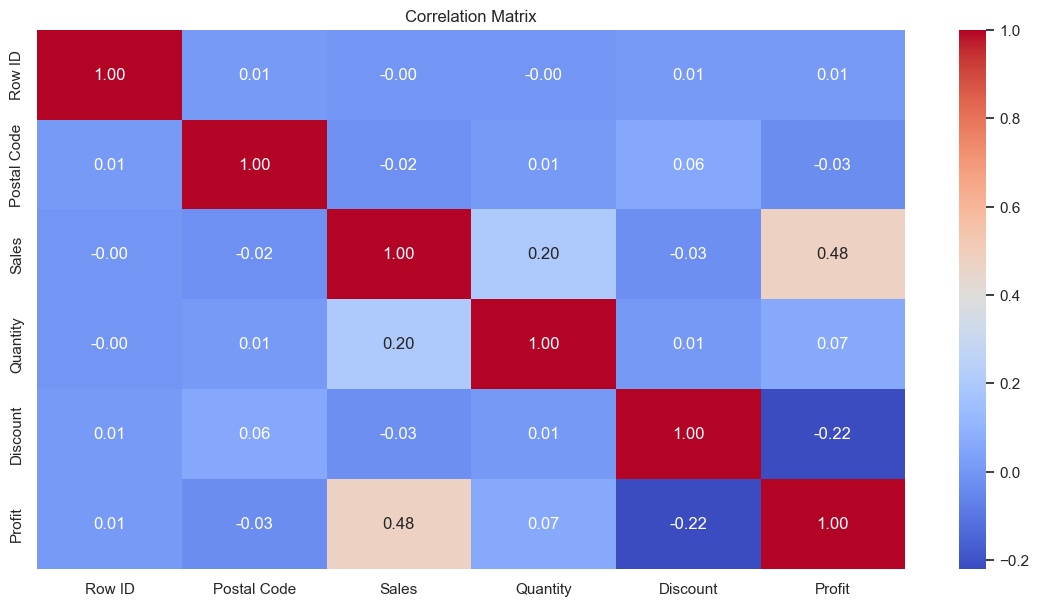

In [23]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Correlation heatmap to check relationships.

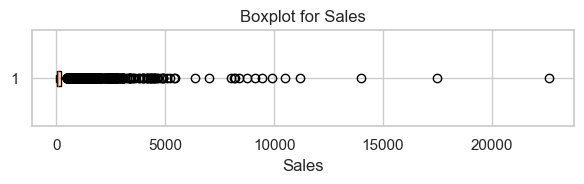

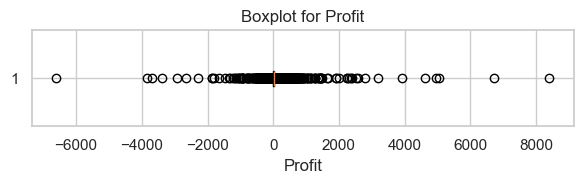

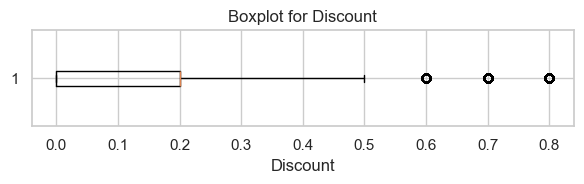

In [24]:
for col in ['Sales', 'Profit', 'Discount']:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Boxplot to detect profit outliers.

### Monthly Sales Trend

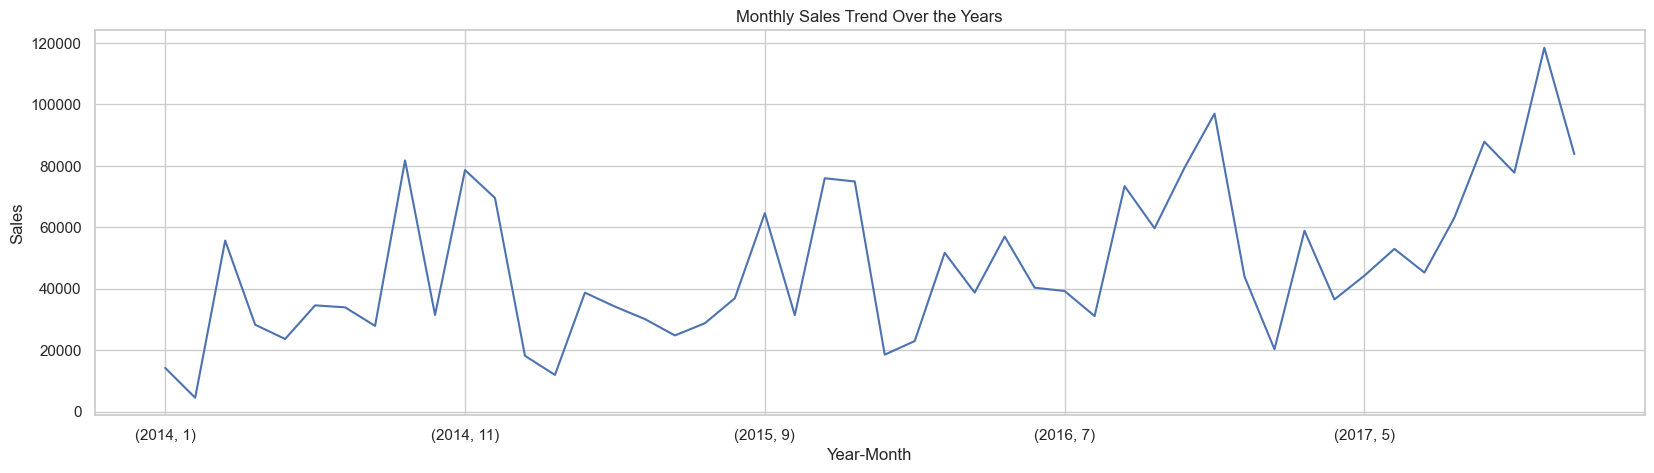

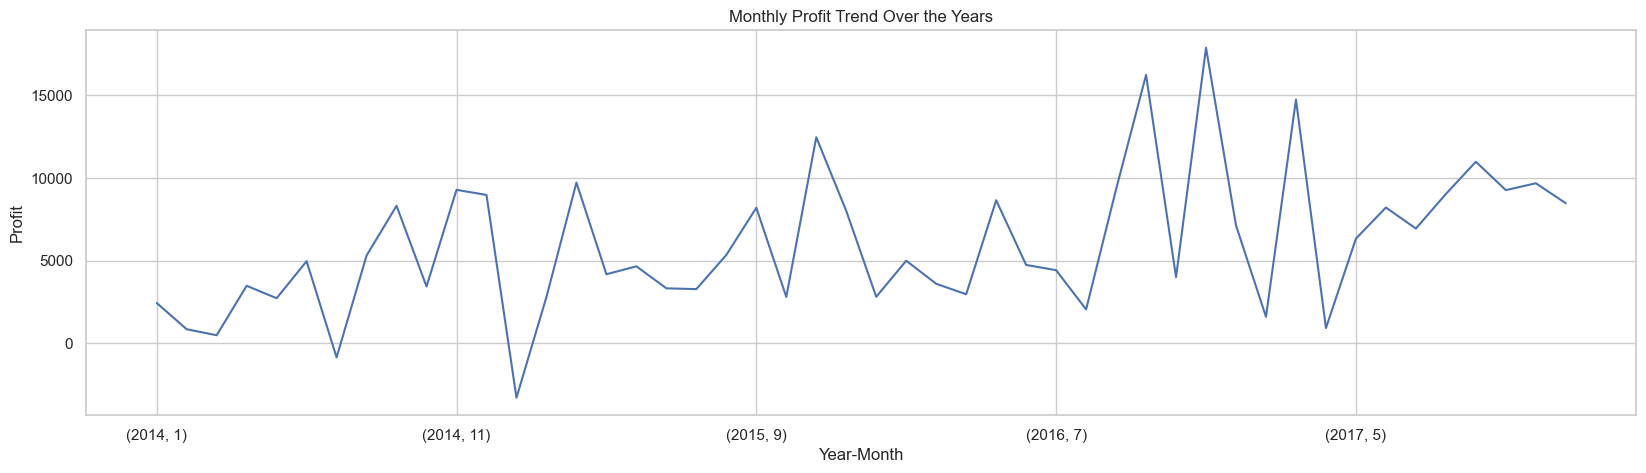

In [25]:
sales_year_month = (df
    .groupby([df['Order Date'].dt.year.rename('Year'),
              df['Order Date'].dt.month.rename('Month')])['Sales']
    .sum()
    .sort_index())

plt.figure(figsize=(20,5))
sales_year_month.plot()
plt.title('Monthly Sales Trend Over the Years')
plt.xlabel('Year-Month'); plt.ylabel('Sales'); plt.show()

profit_year_month = (df
    .groupby([df['Order Date'].dt.year.rename('Year'),
              df['Order Date'].dt.month.rename('Month')])['Profit']
    .sum()
    .sort_index())

plt.figure(figsize=(20,5))
profit_year_month.plot()
plt.title('Monthly Profit Trend Over the Years')
plt.xlabel('Year-Month'); plt.ylabel('Profit'); plt.show()


### Monthly sales trend across years.

### Heatmap - Monthly Sales per Year

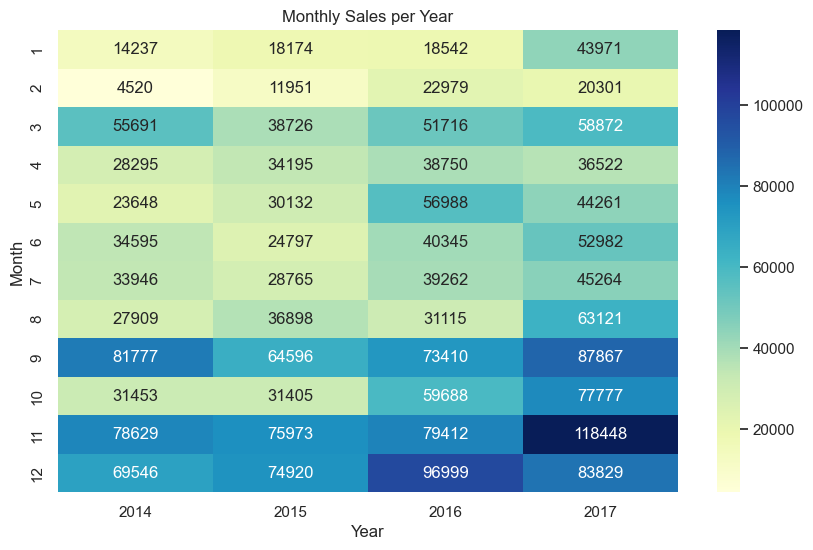

In [26]:
pivot = df.pivot_table(index=df['Order Date'].dt.month, columns=df['Order Date'].dt.year, values='Sales', aggfunc='sum')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Monthly Sales per Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

### Compare December across years to check whether holiday uplift is getting stronger or weaker.

### Line Plot

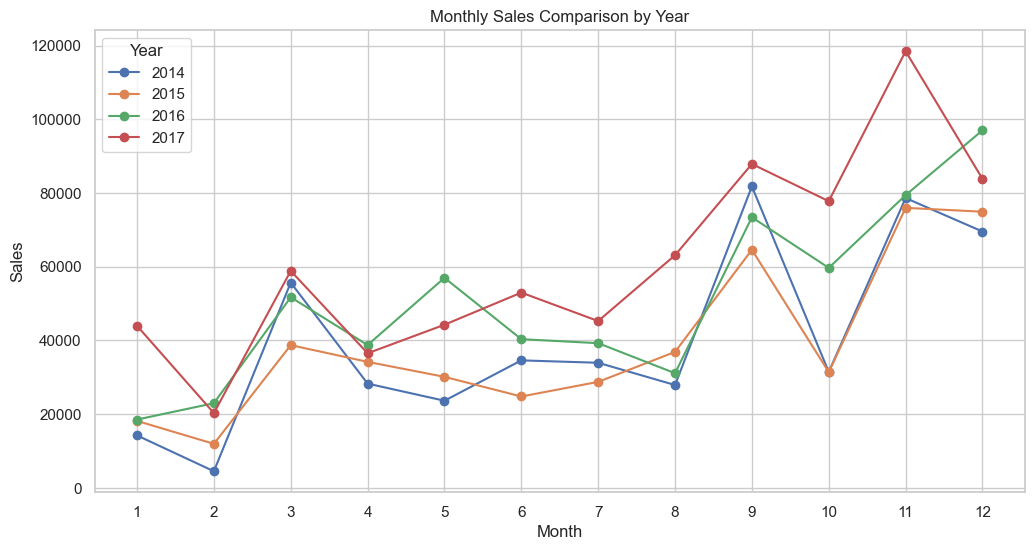

In [27]:
plt.figure(figsize=(12,6))
for year in pivot.columns:
    plt.plot(pivot.index, pivot[year], marker='o', label=str(year))

plt.title('Monthly Sales Comparison by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Year')
plt.xticks(pivot.index)
plt.show()      


### compares intra‑year curves month‑by‑month.

### Bar Plot 

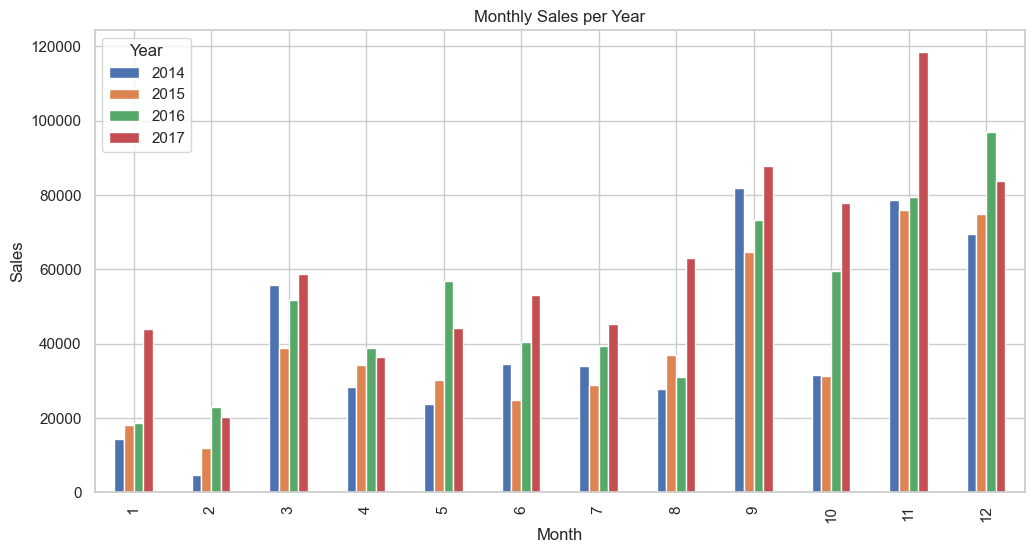

In [28]:
pivot.plot(kind='bar', figsize=(12,6))
plt.title('Monthly Sales per Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Year')
plt.show()

### stacks months side‑by‑side across years.

### Sales vs Profit

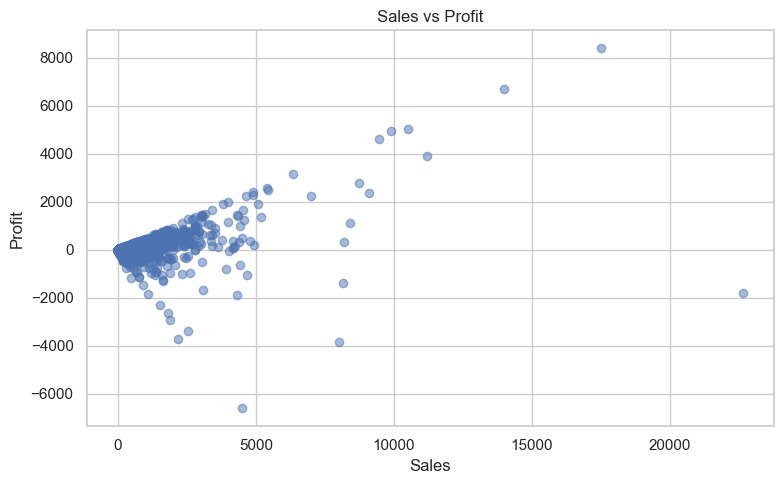

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### Each point is a line item; the slope/horizontal spread hints whether higher sales typically mean higher profit or if discounting freights margins.

### Analysis Sales by Region

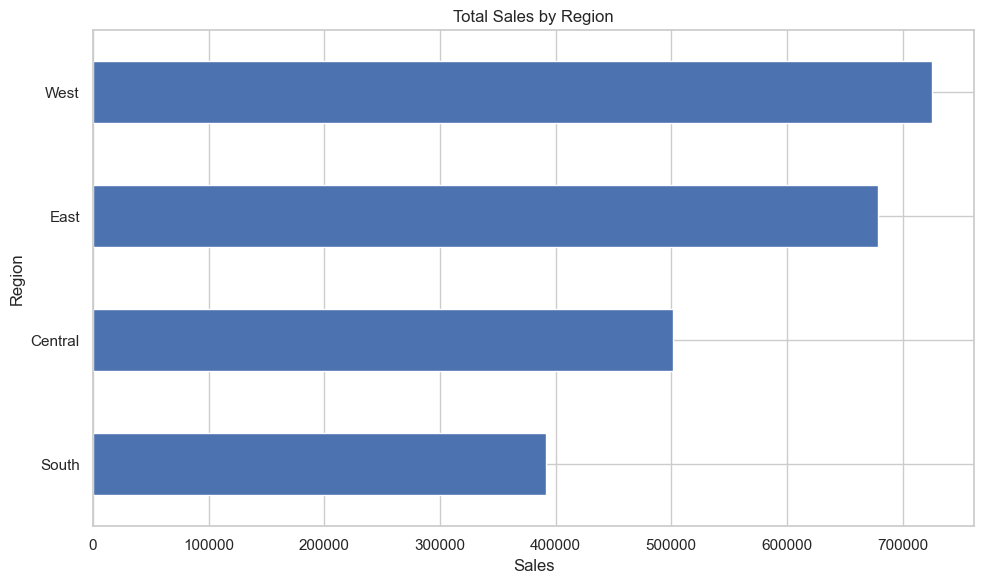

In [30]:
top_regions = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
top_regions.sort_values().plot(kind='barh')
plt.title('Total Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Regional totals identify footprint strength.

### Analysis Sales by States

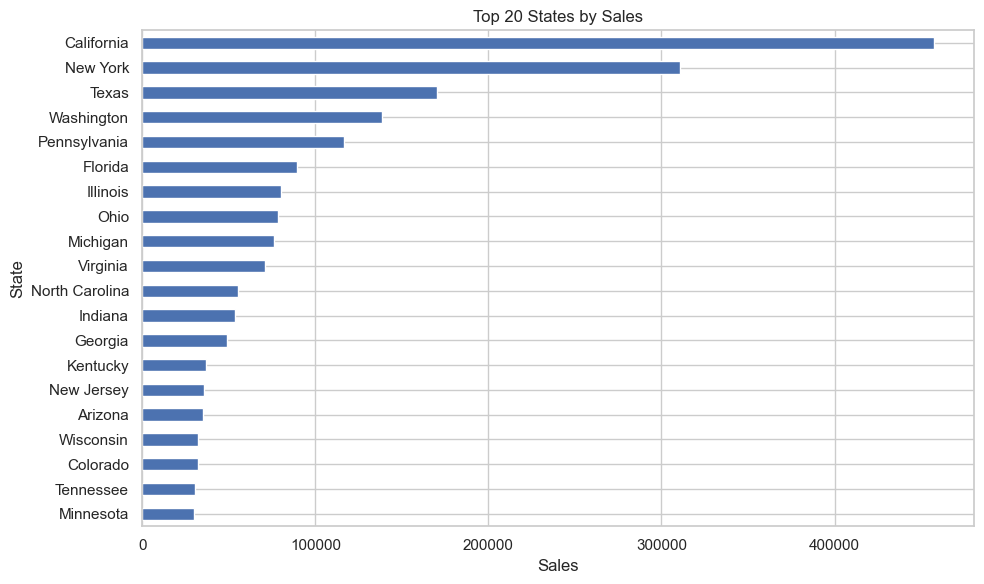

In [31]:
top_States_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_States_sales.sort_values().plot(kind='barh')
plt.title('Top 20 States by Sales')
plt.xlabel('Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### A ranked view of where revenue concentrates.

### Analysis Sales by Cities 

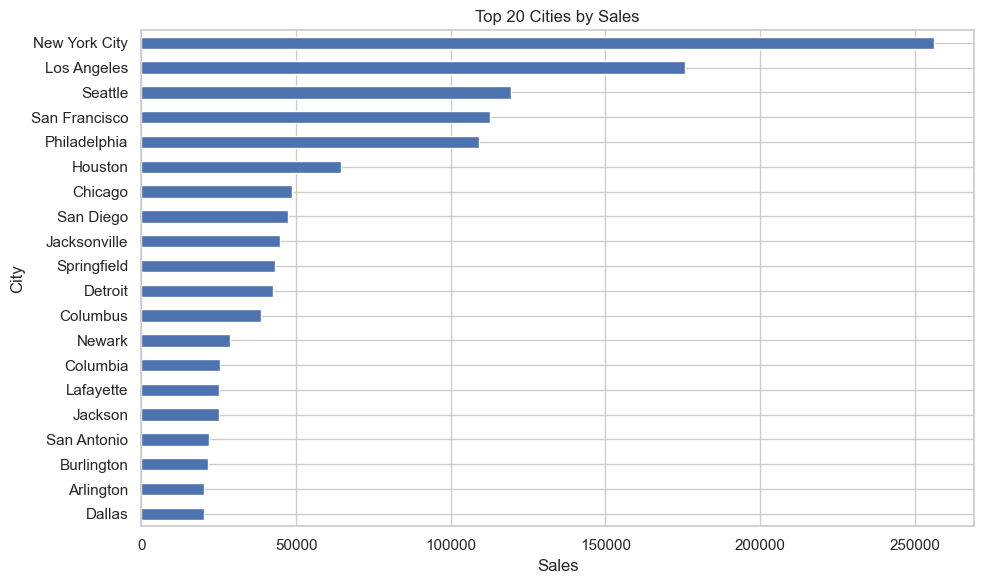

In [32]:
top_Cities_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_Cities_sales.sort_values().plot(kind='barh')
plt.title('Top 20 Cities by Sales')
plt.xlabel('Sales')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Great inputs for geo‑targeted ads and local partnerships.

### Analysis Profit by States 

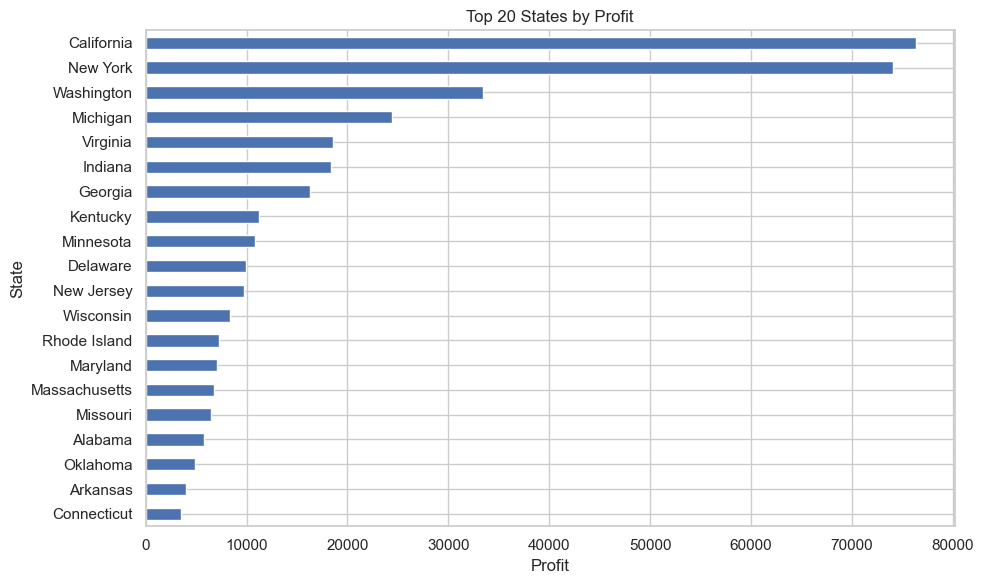

In [33]:
top_States_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_States_profit.sort_values().plot(kind='barh')
plt.title('Top 20 States by Profit')
plt.xlabel('Profit')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### If a high‑sales state is low‑profit, investigate discount policy, returns, and last‑mile costs.

### Analysis Profit by Cities 

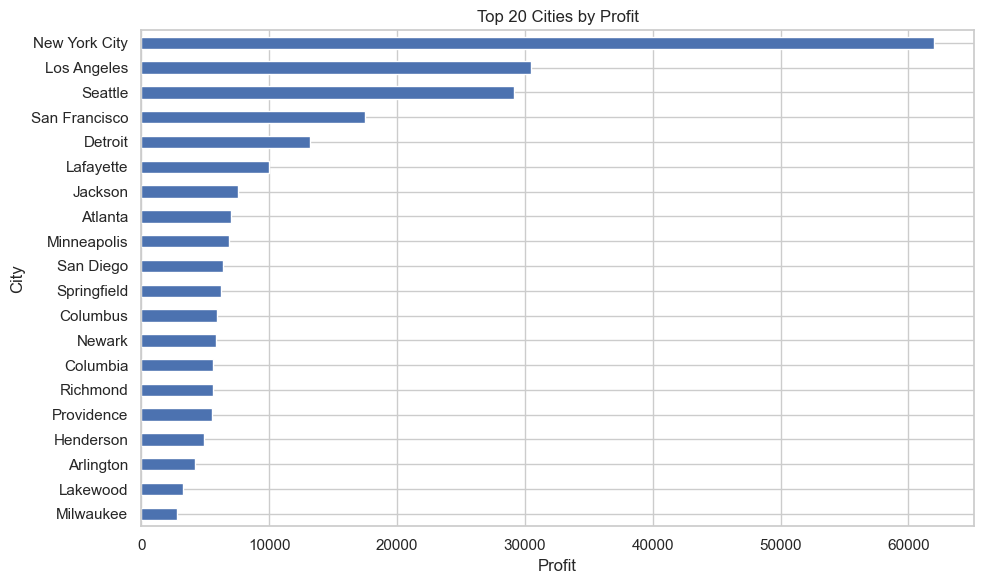

In [34]:
top_Cities_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
top_Cities_profit.sort_values().plot(kind='barh')
plt.title('Top 20 Cities by Profit')
plt.xlabel('Profit')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Use this to allocate account managers and service levels where margin justifies investment.

### Category & Sub-Category Sales Analysis

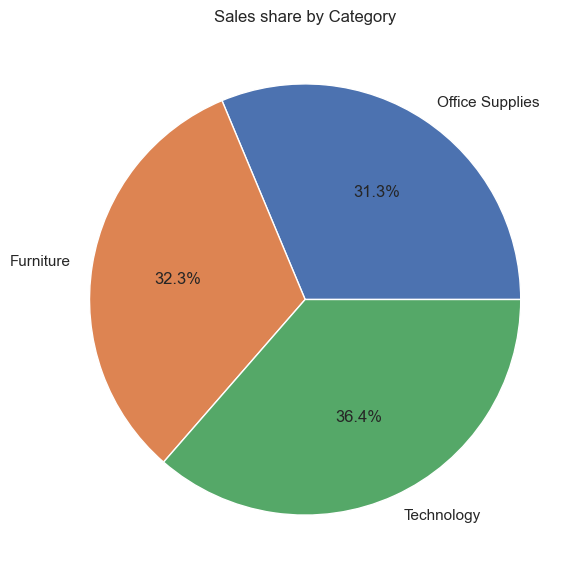

In [35]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(10,7))
cat_sales.plot(kind='pie', autopct='%1.1f%%', title='Sales share by Category')
plt.ylabel('')
plt.show()

### High‑level composition of revenue by Furniture / Office Supplies / Technology.


### Top Products Word Cloud

In [37]:
try:
    from wordcloud import WordCloud
    _txt = " ".join(df.loc[df['Sales'] > df['Sales'].quantile(0.75), 'Product Name'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(_txt)
    plt.imshow(wordcloud, interpolation='bilinear'); plt.axis('off'); plt.title("Top Products Wordcloud")
    plt.show()
except Exception as e:
    print("WordCloud skipped →", e)

WordCloud skipped → No module named 'wordcloud'


### A quick, qualitative sense of products dominating top‑quartile sales.


### Analysis Profit by Category

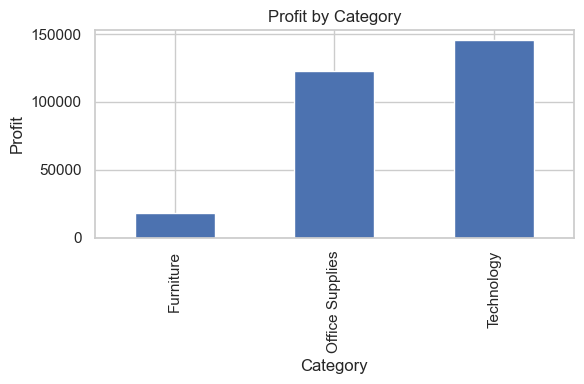

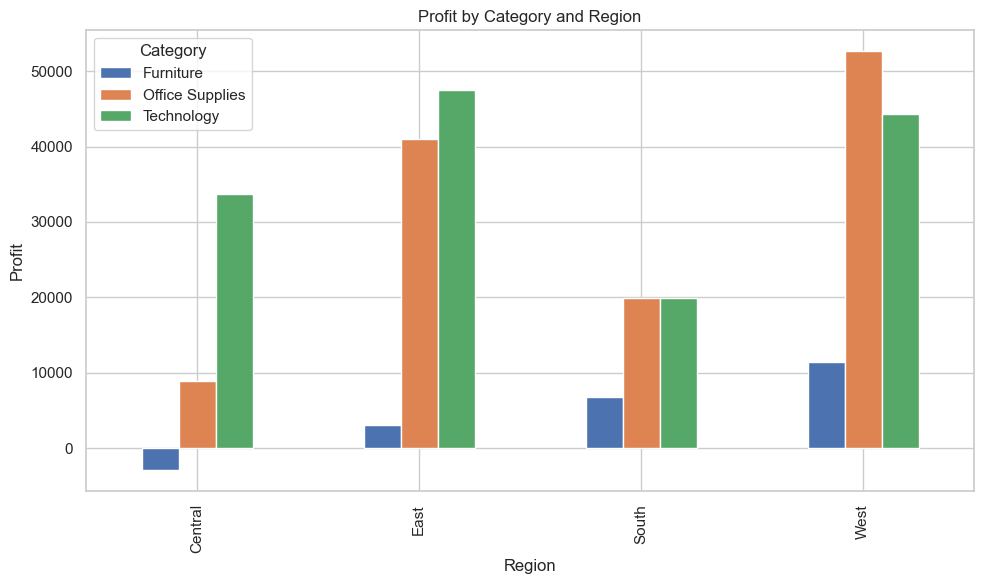

In [39]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values()
plt.figure(figsize=(6,4))
profit_by_category.plot(kind='bar', title='Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

profit_region_category = df.pivot_table(
    index='Region',
    columns='Category',
    values='Profit',
    aggfunc='sum',
)
profit_region_category.plot(kind='bar', figsize=(10, 6))
plt.title('Profit by Category and Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### Category bars show margin strength by line.

### Analysis Discount impact on Profit

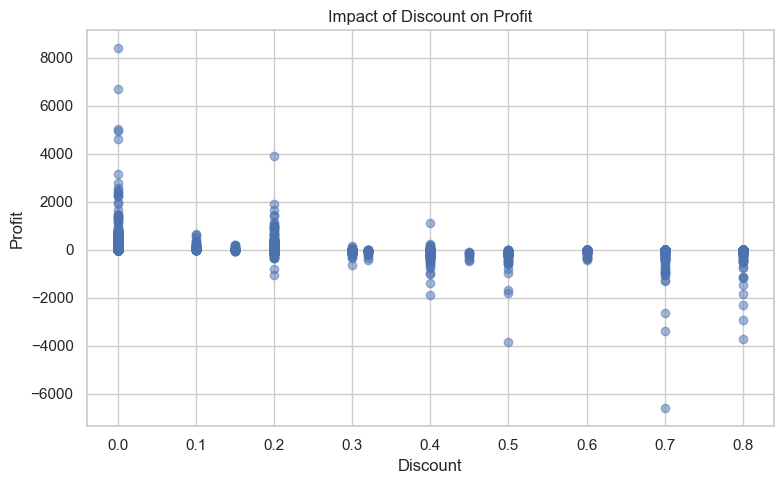

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

### This visual shows whether higher discounts correlate with lower profit.


### Loss-Making Sub-Categories Analysis

In [41]:
loss_products = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)
print('Most Loss-Making Sub-Categories:')
loss_products

Most Loss-Making Sub-Categories:


Sub-Category
Tables        -17,725.481
Bookcases      -3,472.556
Supplies       -1,189.100
Fasteners         949.518
Machines        3,384.757
Labels          5,546.254
Art             6,527.787
Envelopes       6,964.177
Furnishings    13,059.144
Appliances     18,138.005
Name: Profit, dtype: float64

### We rank sub‑categories with lowest total profit.


### Profit Distribution

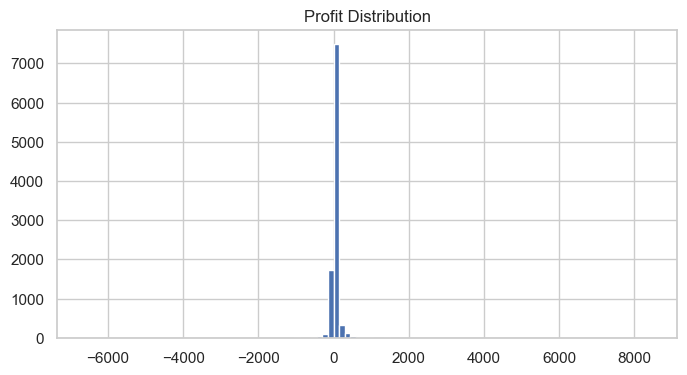

Profit Range: -6599.978 → 8399.976


In [42]:
plt.figure(figsize=(8,4))
plt.hist(df['Profit'], bins=100)
plt.title('Profit Distribution')
plt.show()
print("Profit Range:", df['Profit'].min(), "→", df['Profit'].max())


### We check the symmetry and tails of profit at the line level.


### Analysis Top Customers Sales

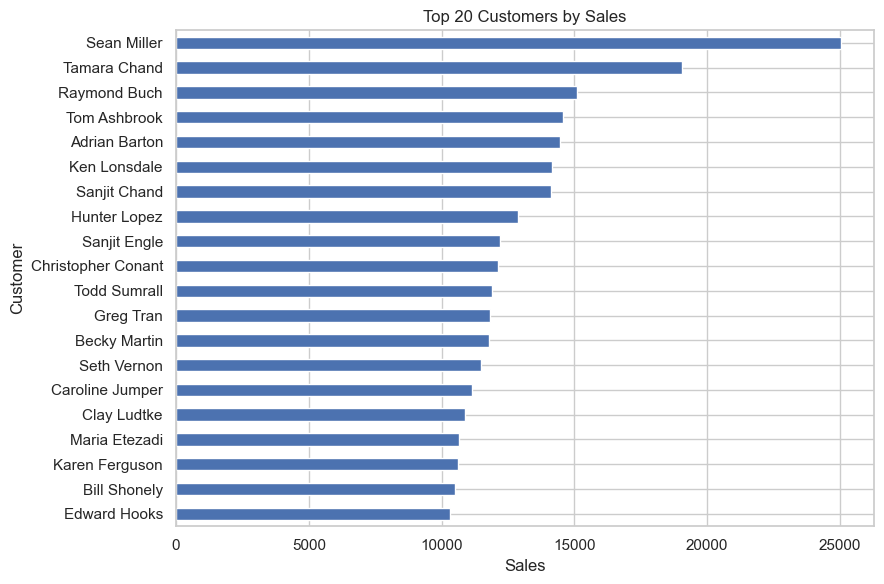

In [43]:
top_customers_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 6))
top_customers_sales.sort_values().plot(kind='barh')
plt.title('Top 20 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

### Identifies our whales—key for VIP programs, priority support, and contract renewals.

### Analysis Top Customers Profit

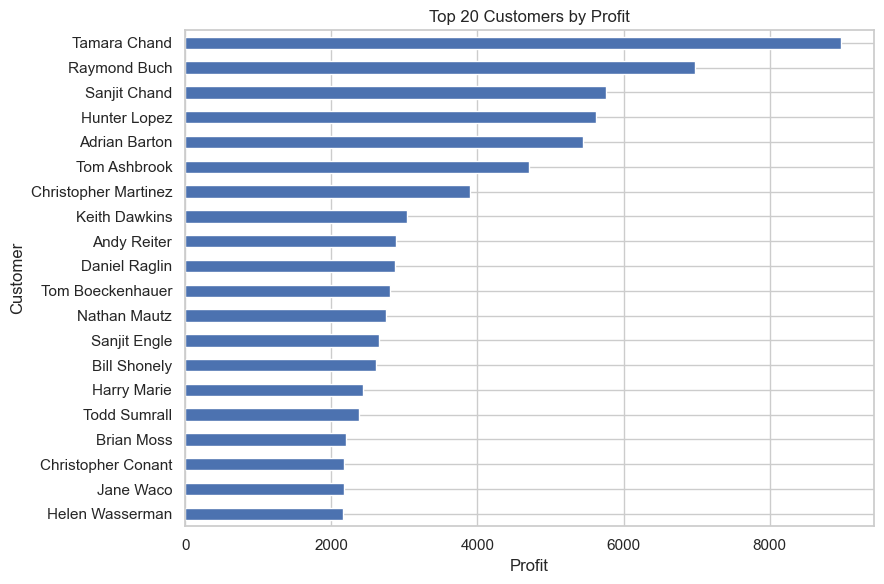

In [44]:
top_customers_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 6))
top_customers_profit.sort_values().plot(kind='barh')
plt.title('Top 20 Customers by Profit')
plt.xlabel('Profit')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

### Revenue is vanity, profit is sanity.


### Total Profit Margin by Category

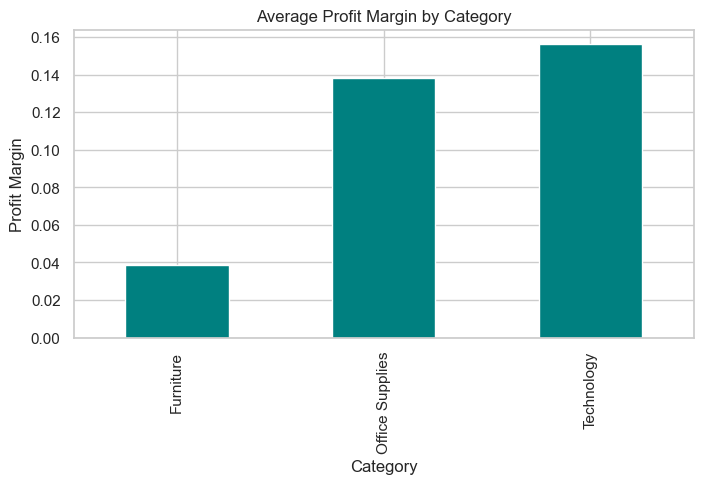

In [45]:
avg_margin_by_cat = (df['Profit'] / df['Sales']).replace([np.inf, -np.inf], np.nan)
margin_by_category = df.assign(_pm=avg_margin_by_cat).groupby('Category')['_pm'].mean().sort_values()
plt.figure(figsize=(8,4))
margin_by_category.plot(kind='bar', color='teal')
plt.title('Average Profit Margin by Category')
plt.ylabel('Profit Margin')
plt.show()


### We compute line‑level margin and average by category.


### Total Sales by Sub-Category

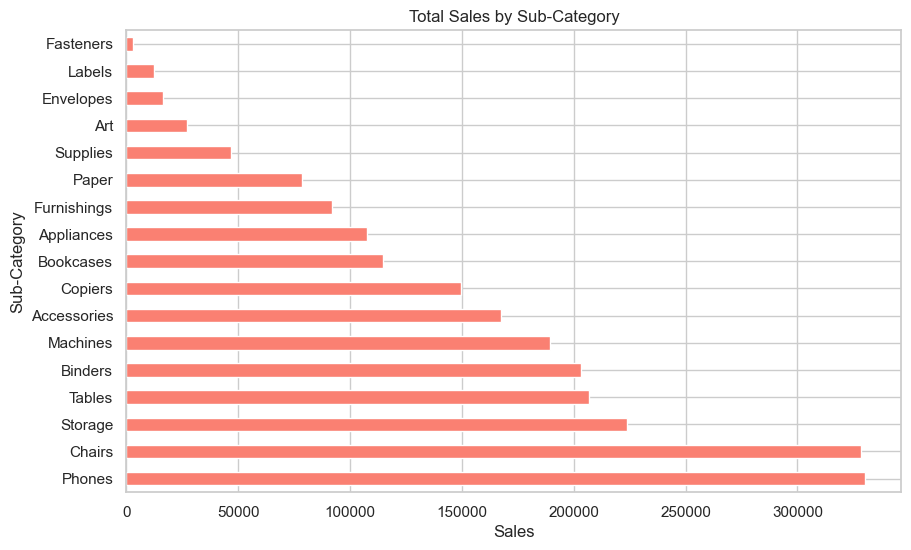

In [46]:
subcat_by_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
subcat_by_sales.plot(kind='barh', color='salmon')
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show()


### Great for merchandising decisions and shelf space allocation.

### Total Profit by Sub-Category

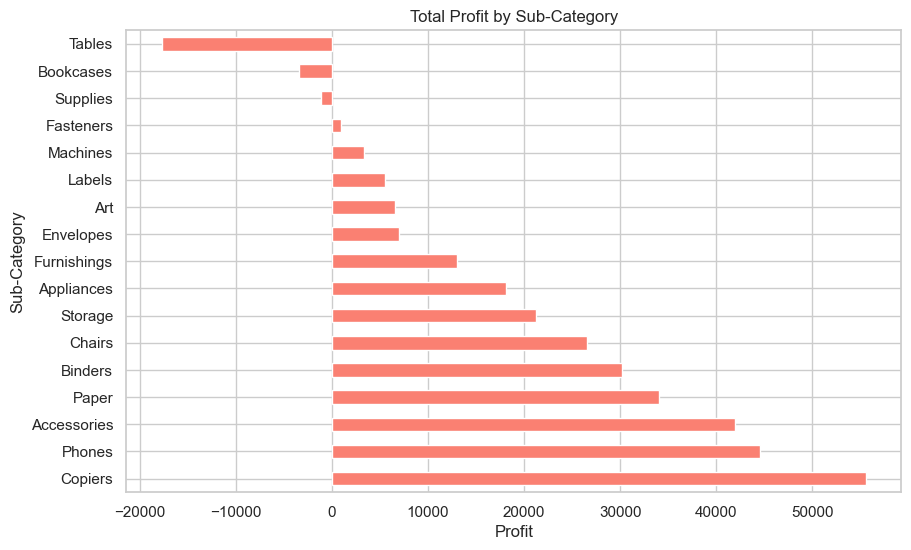

In [47]:
subcat_by_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
subcat_by_profit.plot(kind='barh', color='salmon')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()


### Great for merchandising decisions and shelf space allocation.

### Shipping Time Distribution

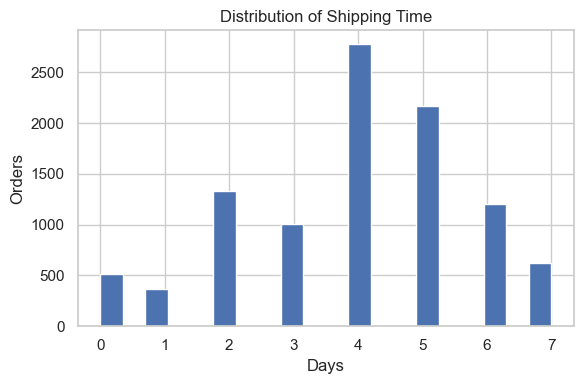

In [48]:
shipping_time = (df['Ship Date'] - df['Order Date']).dt.days.clip(lower=0)
plt.figure(figsize=(6,4))
plt.hist(shipping_time, bins=20)
plt.title('Distribution of Shipping Time')
plt.xlabel('Days')
plt.ylabel('Orders')
plt.tight_layout()
plt.show()

### Shorter, more predictable shipping improves conversion and reduces returns.


### Yearly Sales/Profit


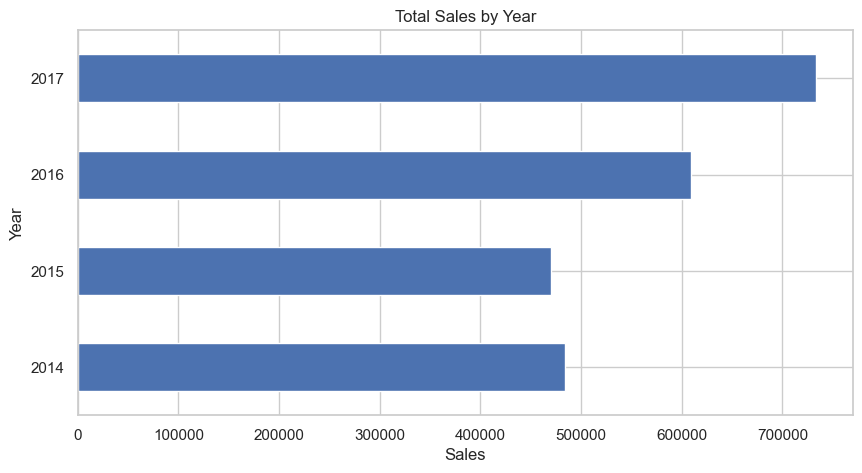

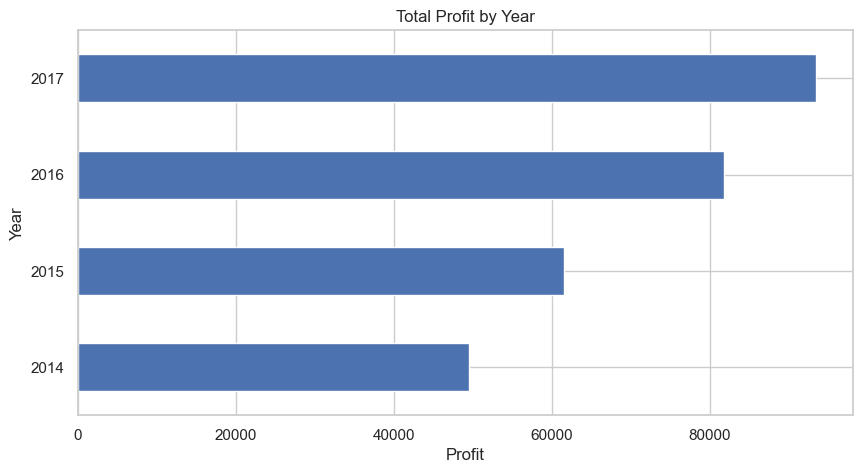

In [50]:
df_year = df.assign(OrderY=df['Order Date'].dt.year)
plt.figure(figsize=(10,5)); df_year.groupby('OrderY')['Sales'].sum().plot.barh()
plt.title('Total Sales by Year'); plt.xlabel('Sales'); plt.ylabel('Year'); plt.show()
plt.figure(figsize=(10,5)); df_year.groupby('OrderY')['Profit'].sum().plot.barh()
plt.title('Total Profit by Year'); plt.xlabel('Profit'); plt.ylabel('Year'); plt.show()

### Use alongside seasonality plots for a full temporal story.

### Key Business Metrics (KPIs)

In [51]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
total_orders = df['Order ID'].nunique()
unique_customers = df['Customer ID'].nunique()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Average Order Value: {avg_order_value:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Unique Customers: {unique_customers}")


Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Order Value: 458.61
Total Orders: 5009
Unique Customers: 793


### We compute:

### Total Sales / Profit

### Average Order Value (AOV)

### Orders & Unique Customers

### This anchors the analysis in a few board‑level metrics.

### Trend Smoothing - Moving Average

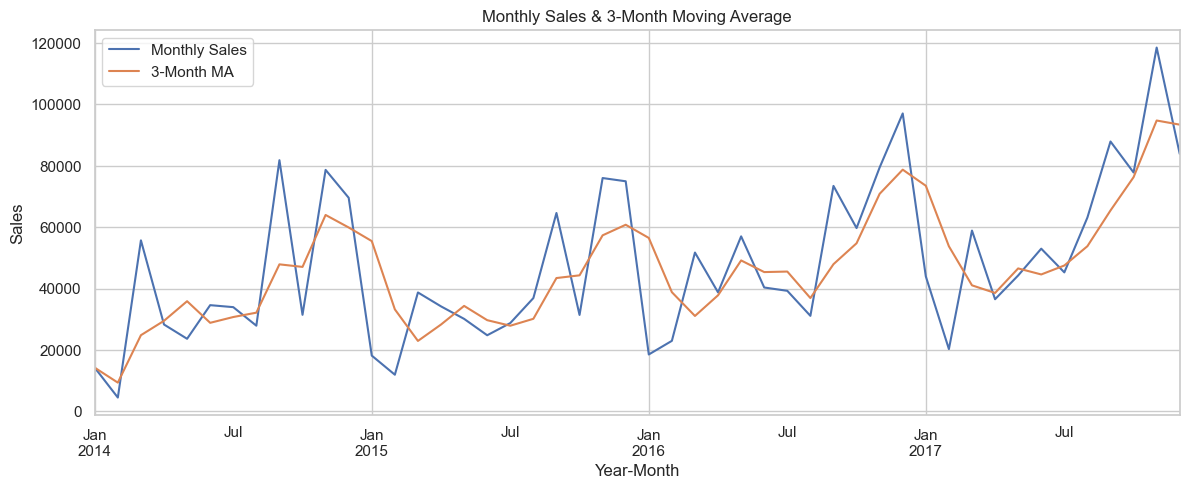

In [52]:
sales_month_smooth = sales_month_by_period.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(14,5))
sales_month_by_period.plot(label='Monthly Sales')
sales_month_smooth.plot(label='3-Month MA')  
plt.title('Monthly Sales & 3-Month Moving Average')
plt.xlabel('Year-Month'); plt.ylabel('Sales'); plt.legend(); plt.show()


### We overlay a 3‑month moving average onto monthly sales.


### Seasonal Decomposition of Sales (Time Series Analysis)

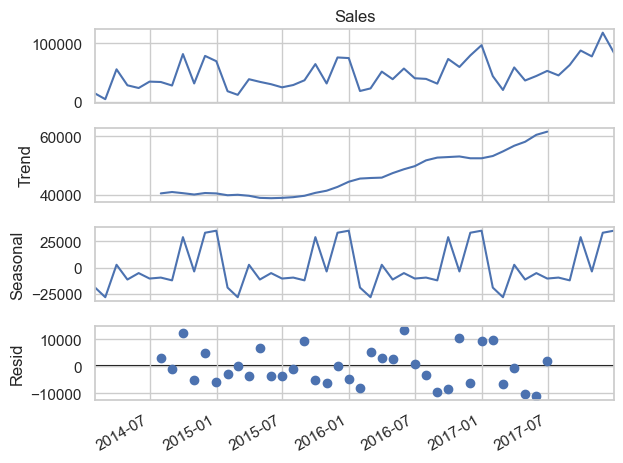

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose
sales_m = sales_month_by_period.asfreq('M').fillna(0)
res = seasonal_decompose(sales_m, model='additive', period=12)
res.plot(); plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

### Perfect for justifying inventory staging and campaign calendars.

### Cohort Analysis – Customer Retention Over Time

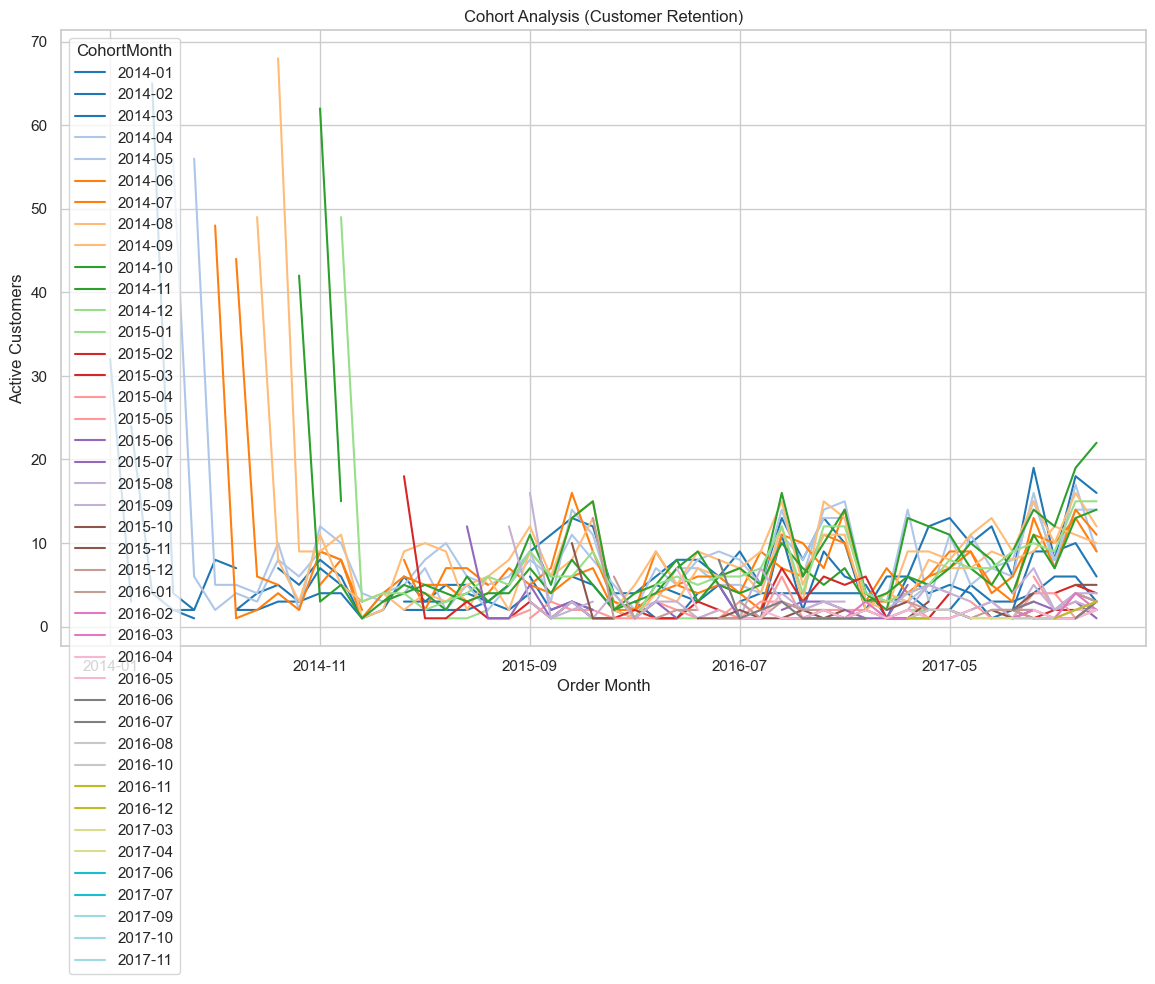

In [54]:
df_cohort = df.copy()
df_cohort['YearMonth'] = df_cohort['Order Date'].dt.to_period('M').astype(str)
df_cohort['CohortMonth'] = df_cohort.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M').astype(str)
cohort_data = df_cohort.groupby(['CohortMonth','YearMonth'])['Customer ID'].nunique().unstack(0)
cohort_data.plot(figsize=(14,8), cmap='tab20', title='Cohort Analysis (Customer Retention)')
plt.xlabel('Order Month'); plt.ylabel('Active Customers'); plt.show()


### Cohort analysis shows strong first-month retention but a drop-off after 3–4 months, indicating need for re-engagement campaigns.

### RFM Analysis

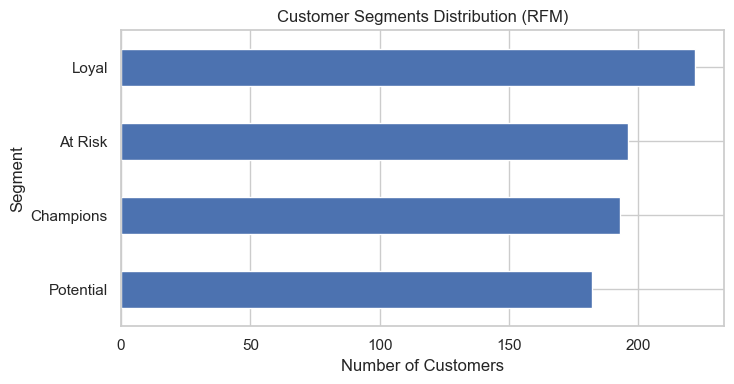

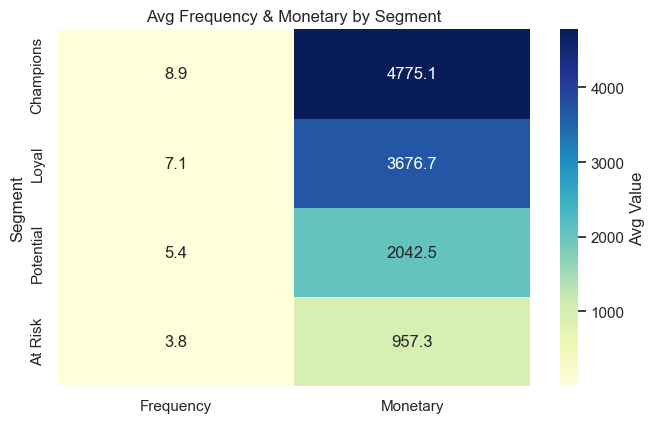

,Recency,Frequency,Monetary
Segment,,,
Champions,36.800000,8.900000,4775.100000
Loyal,92.600000,7.100000,3676.700000
Potential,150.100000,5.400000,2042.500000
At Risk,317.500000,3.800000,957.300000


In [55]:
today = df['Order Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (today - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum'),
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
rfm[['R_Score', 'F_Score', 'M_Score']] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int)
rfm['RFM_Sum'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

def segment_map(score):
    if score >= 10:
        return 'Champions'
    if score >= 8:
        return 'Loyal'
    if score >= 6:
        return 'Potential'
    return 'At Risk'

rfm['Segment'] = rfm['RFM_Sum'].apply(segment_map)

plt.figure(figsize=(7.5, 4))
rfm['Segment'].value_counts().sort_values().plot(kind='barh')
plt.title('Customer Segments Distribution (RFM)')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

seg_kpis = (
    rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(1)
    .sort_values('Monetary', ascending=False)
)

plt.figure(figsize=(6.8, 4.4))
sns.heatmap(
    seg_kpis[['Frequency', 'Monetary']],
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Avg Value'},
)
plt.title('Avg Frequency & Monetary by Segment')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

try:
    display(seg_kpis.style.background_gradient(cmap='YlGnBu'))
except Exception:
    display(seg_kpis)

## Predictive Modeling — Order-Line Profit

This section builds a baseline model to estimate **profit per order line** from known transaction attributes.

The model is intended for pricing and margin analytics, not for forecasting future monthly sales.

##  Machine Learning Pipeline for Profit Prediction

![ML Pipeline](https://copilot.microsoft.com/th/id/BCO.ddb2ede1-b99d-4030-a8b6-2d04369d4fc9.png)


## Modeling Scope and Assumptions

The target is:

```text
Profit
```

The features represent information that can be known once the order line is created or priced, such as:

- product category and sub-category
- customer segment and region
- sales amount, quantity, and discount
- order month and year

To reduce leakage and identifier noise, the model excludes:

- direct identifiers such as `Row ID`, `Order ID`, `Customer ID`, and product/customer names
- target-derived fields such as `Profit Margin`
- shipping outcome fields such as `Shipping Time`
- raw datetime fields after extracting useful calendar features

For a production deployment, the exact feature set should match the moment when the prediction is made.

## 🛠️ Feature Engineering

**Definition:**  
Feature Engineering is the process of **creating, transforming, or selecting variables (features)** from raw data to improve the performance of a Machine Learning model.

### 🎯 Objectives
- Convert raw data into **meaningful signals** for algorithms.  
- Improve **accuracy, efficiency, and interpretability** of models.  
- Reduce noise and prevent **overfitting**.

### 🔎 Main Steps
1. **[Feature Creation](ca://s?q=Feature_creation_in_ML)** → build new variables (e.g., `Profit Margin = Profit / Sales`).  
2. **[Feature Transformation](ca://s?q=Feature_transformation_in_ML)** → modify existing variables (e.g., scaling, encoding categorical data).  
3. **[Feature Selection](ca://s?q=Feature_selection_in_ML)** → choose the most relevant variables to keep the model efficient.

### 📊 Example (Superstore Dataset)
- Raw feature: `Order Date`  
- Engineered feature: `Month of Order` (to capture seasonality).  
- Raw features: `Sales` and `Profit`  
- Engineered feature: `Profit Margin %` (to measure profitability).  

### ✅ Summary
Feature Engineering is the **art of turning raw data into smart features**, enabling models to **learn patterns more effectively** and produce better predictions.


In [56]:
df_model = df.copy().sort_values("Order Date").reset_index(drop=True)

df_model["OrderY"] = df_model["Order Date"].dt.year
df_model["OrderM"] = df_model["Order Date"].dt.month
df_model["Discounted Sales"] = df_model["Sales"] * (1 - df_model["Discount"])
df_model["Sales per Quantity"] = (df_model["Sales"] / df_model["Quantity"]).replace([np.inf, -np.inf], np.nan)

# Target-derived and operational fields are created for analysis, then excluded from model features.
df_model["Profit Margin"] = (df_model["Profit"] / df_model["Sales"]).replace([np.inf, -np.inf], np.nan)
df_model["Shipping Time"] = (df_model["Ship Date"] - df_model["Order Date"]).dt.days.clip(lower=0)

We add model-ready features:

- `OrderY` and `OrderM` for calendar seasonality
- `Discounted Sales` and `Sales per Quantity` for price and discount behavior
- `Profit Margin` only for diagnostics; it is excluded from modeling because it is target-derived
- `Shipping Time` only for EDA; it is excluded from modeling because it is not available at order creation time

For a stable baseline, the next step removes the most extreme 1% tails of profit. This keeps the model focused on regular operating behavior while preserving extreme-loss analysis in the EDA section.

### Outliers on profit

In [57]:
q_low, q_high = df_model["Profit"].quantile([0.01, 0.99])
rows_before = len(df_model)

df_model = (
    df_model[(df_model["Profit"] > q_low) & (df_model["Profit"] < q_high)]
    .sort_values("Order Date")
    .reset_index(drop=True)
)

rows_after = len(df_model)
print(f"Profit modeling range: {q_low:,.2f} to {q_high:,.2f}")
print(f"Rows kept for modeling: {rows_after:,} / {rows_before:,} ({rows_after / rows_before:.1%})")

Profit modeling range: -319.26 to 580.66
Rows kept for modeling: 9,794 / 9,994 (98.0%)



---
👉 This is indeed an **outlier removal step using the IQR/quantile method**. It’s a common preprocessing technique to make models more robust by excluding extreme values.  


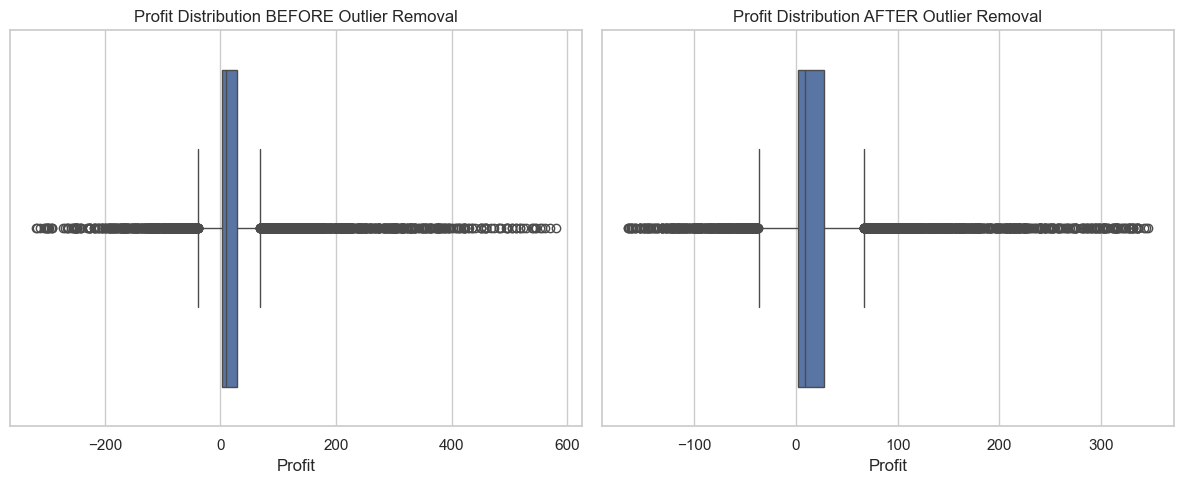

In [58]:
# Before filtering
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df_model["Profit"])
plt.title("Profit Distribution BEFORE Outlier Removal")

# Apply filtering (1st to 99th percentile)
q_low, q_high = df_model["Profit"].quantile([0.01, 0.99])
df_filtered = df_model[(df_model["Profit"] > q_low) & (df_model["Profit"] < q_high)]

# After filtering
plt.subplot(1,2,2)
sns.boxplot(x=df_filtered["Profit"])
plt.title("Profit Distribution AFTER Outlier Removal")

plt.tight_layout()
plt.show()


*outliers can distort statistical measures (like mean, variance) and make modeling less reliable.*

*After remove outliers :  means the majority of data points are now closer to the center, reducing noise for analysis.*

## 🎯 Target and Feature Selection

This code prepares the dataset for **machine learning modeling** by separating the target variable (`Profit`) from the features (predictors):

1. **Define the target variable**
   ```python
   target = "Profit"
   y = df_model[target].copy()
   X = df_model[feature_cols].copy()


In [59]:
target = "Profit"

drop_cols = [
    target,
    "Profit Margin",
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Postal Code",
    "City",
    "Country",
    "Order Date",
    "Ship Date",
    "Shipping Time",
    "CohortMonth",
]

feature_cols = [col for col in df_model.columns if col not in drop_cols]

X = df_model[feature_cols].copy()
y = df_model[target].copy()

print(f"Feature count: {X.shape[1]}")
display(pd.DataFrame({"feature": X.columns.tolist()}))

Feature count: 13


,feature
0,Ship Mode
1,Segment
2,State
3,Region
4,Category
5,Sub-Category
6,Sales
7,Quantity
8,Discount
9,OrderY


The model uses a clean feature matrix that excludes identifiers, target-derived fields, and post-order shipping outcomes.

This keeps the baseline closer to a realistic pricing and margin scoring workflow.

### Remove datetime/period-like from X

In [60]:
datetime_like = X.select_dtypes(include=["datetime64[ns]", "timedelta64[ns]"]).columns.tolist()
X = X.drop(columns=datetime_like, errors="ignore")

if datetime_like:
    print(f"Dropped datetime-like columns from X: {datetime_like}")
else:
    print("No datetime-like columns found in X.")

No datetime-like columns found in X.


*current feature set (X) does not contain any columns with a datetime64[ns] or timedelta64[ns] data type, the ns stands for nanosecond precision.*

### Identify Types 

In [61]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

assert len(X) == len(y)

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features: 7
Categorical features: 6


#### Identify numeric and categorical features

In [62]:

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Display them
print("Numeric Features:")
display(pd.DataFrame({"Numeric Feature": numeric_cols}))

print("Categorical Features:")
display(pd.DataFrame({"Categorical Feature": categorical_cols}))

# Quick interpretation
print(f"Total numeric features: {len(numeric_cols)}")
print(f"Total categorical features: {len(categorical_cols)}")


Numeric Features:


,Numeric Feature
0,Sales
1,Quantity
2,Discount
3,OrderY
4,OrderM
5,Discounted Sales
6,Sales per Quantity


Categorical Features:


,Categorical Feature
0,Ship Mode
1,Segment
2,State
3,Region
4,Category
5,Sub-Category


Total numeric features: 7
Total categorical features: 6


##  Result Interpretation

- **Numeric features: 7**  
  These are continuous or discrete values that can be directly used in modeling (after scaling).  
  They represent measurable quantities such as:
  - Sales  
  - Quantity  
  - Discount  
  - Discounted Sales  
  - Sales per Quantity  
  - Order Year (OrderY)  
  - Order Month (OrderM)  

- **Categorical features: 6**  
  These are labels or categories that describe qualitative aspects of the data.  
  They need encoding (e.g., one-hot encoding) before being used in a model.  
  Examples include:
  - Ship Mode  
  - Segment  
  - State  
  - Region  
  - Category  
  - Sub-Category  

###  Meaning
- Your dataset is now split into **7 numeric predictors** and **6 categorical predictors**, giving a total of **13 features**.  
- This balance is important because:
  - Numeric features capture **quantitative drivers of profit** (e.g., sales volume, discounts).  
  - Categorical features capture **business context** (e.g., customer type, product type, geography).  
- By separating them, you can apply the **right preprocessing**:
  - [Scaling numeric features](ca://s?q=Scaling_numeric_features) (StandardScaler, MinMaxScaler).  
  - [Encoding categorical features](ca://s?q=Encoding_categorical_features) (OneHotEncoder, LabelEncoder).  

---

 In short: the result confirms that your dataset is well-structured for machine learning — with a clear split between numeric and categorical features, ready for preprocessing and model training.


### We separate columns by dtype to build type‑specific preprocessors (median impute for numbers, most‑frequent + OHE for categories).

## Preprocessing Encoder 

## Preprocessing design: Why we use ColumnTransformer + median imputation + mode imputation + OHE with handle_unknown='ignore'

## The problem
Real datasets mix numeric and categorical columns. They also contain missing values (NaNs) and may see new categories after training. A single preprocessing rule fails.

## Solution structure (ColumnTransformer)
We apply different pipelines to different column groups:
- Numeric columns → median imputation
- Categorical columns → most‑frequent imputation → One‑Hot Encoding

---

## 1. Numeric pipeline: median imputation
**What is imputation?** Replacing missing values with a statistical estimate. ML models cannot handle NaN.

**Why median, not mean?**  
- Median = middle value when sorted. Example: [1, 2, 100] → median = 2, mean ≈ 34.3.  
- Median is **robust to outliers** (extreme values don't pull it away). Mean can be distorted by one very large/small number.  
- For skewed data (e.g., income, house prices), median better represents the "typical" value.

**Effect:** Every NaN in a numeric column becomes the column's median (calculated only on training data).

---

## 2. Categorical pipeline

### 2.1 Most‑frequent imputation
**What?** Replace missing categories with the **mode** (the most common category).  
**Why not "unknown" or a new token?**  
- Mode preserves the original distribution.  
- Creating a new "missing" category adds a dimension that may not exist in production.  
- Simple and effective when missing rate is low.

### 2.2 One‑Hot Encoding (OHE)
**What?** Converts each category into a separate binary column (0/1).  
**Why OHE over LabelEncoder (Rouge=1, Vert=2)?**  
- LabelEncoder invents an **order** (2 > 1) that does not exist in nominal categories. Linear models, neural networks, etc. would wrongly assume "Bleu > Vert > Rouge".  
- OHE removes any ordinal bias.

**Example:** City = ['Paris','London','Berlin'] →  
Paris | London | Berlin  
1     | 0      | 0  
0     | 1      | 0  
0     | 0      | 1  

### 2.3 `handle_unknown='ignore'` (critical for production)
During **training**, OHE learns the categories (e.g., 'Paris','London','Berlin').  
During **prediction**, a new category might appear (e.g., 'Rome').

**Without `ignore`:** scikit‑learn throws an error because 'Rome' was not seen before.  
**With `ignore`:** the row with 'Rome' gets **all zeros** across the OHE columns (no crash). This is safe because all original categories are absent, so the model sees a zero vector – effectively treating it as "other".

**Why is this robust?** Data drifts over time. New products, cities, job titles appear. `ignore` keeps your pipeline alive without retraining.

---

## Putting it all together
- `ColumnTransformer` ensures numeric columns only get numeric transformers, categorical only get categorical ones.  
- Missing values are handled separately per type (median for numbers, mode for categories).  
- OHE avoids artificial ordering.  
- `handle_unknown='ignore'` prevents crashes from unseen categories at test time.

## Result
An ML pipeline that is:
- **Complete** (no missing values)  
- **Numerically valid** (all inputs are numbers)  
- **Production‑ready** (gracefully handles new categories)

In [63]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
# For numeric features: missing values are replaced with the median.
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
# Replaces missing categorical values with the mode (the most common category).


# Then One‑Hot Encoding transforms categories into binary indicator columns.
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols) if numeric_cols else ("num", "drop", []),
        ("cat", cat_pipe, categorical_cols) if categorical_cols else ("cat", "drop", []),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

*For numeric features: missing values are replaced with the median*
*example :[25, 30, NaN, 35, 32] → sorted = [25,30,32,35] → median =(30+32)/2=31. NaN → 31,*

### ColumnTransformer applies:
### Numeric pipeline: median imputation
### Categorical pipeline: most‑frequent imputation + OHE (with handle_unknown='ignore')
### This makes the ML pipeline robust to missing values and unseen categories.

## Base model inside Pipeline

In [64]:
rf = RandomForestRegressor(
    n_estimators=25,
    max_depth=14,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=1,
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", rf),
])

*Raw Data → Preprocess (imputation, encoding, scaling) → RandomForestRegressor → Predictions.*

## 🌲 Random Forest Algorithm : 
**Bagging (Bootstrap Aggregating)**

This diagram illustrates how Random Forest builds multiple decision trees on bootstrap samples and combines their predictions through averaging or voting.

![Random Forest Algorithm](https://copilot.microsoft.com/th/id/BCO.13a790e0-a88d-4ec9-8187-23981711bb01.png)



### 🔎 Concept
Random Forest is an **ensemble learning method** that builds multiple decision trees and combines their outputs:
- Each tree is trained on a **bootstrap sample** of the data.
- At each split, a random subset of features is considered.
- Predictions are aggregated (majority vote for classification, average for regression).

This reduces overfitting and improves generalization compared to a single decision tree.

---

### 🎯 Supervised or Unsupervised?
- **Random Forest is a *supervised learning algorithm*.**
- It requires **labeled data**:
  - For **classification**, labels are categories (e.g., spam vs. not spam).
  - For **regression**, labels are continuous values (e.g., predicting house prices).
- The model learns to map inputs → outputs using these labels.

---

### ✅ Key Advantages
- Handles both **classification** and **regression** tasks.
- Robust to noise and overfitting.
- Works well with high-dimensional data.

---

### 📊 Summary
- **Type:** Supervised learning  
- **Core idea:** Train many decision trees → combine their predictions  
- **Use cases:** Classification (spam detection, medical diagnosis), Regression (price prediction, risk modeling)


### We wrap preprocessing + model in one Pipeline.
### Benefits: no leakage, repeatable transforms, and clean fit/predict

## Time-Based Train/Test Split

In [65]:
split_idx = int(len(X) * 0.80)
# Uses .iloc slicing to keep the first 80 % for training and the last 20 % for testing.
# .copy() avoids pandas’ view warnings and ensures independent data frames.
X_train = X.iloc[:split_idx].copy() 
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()
# Takes 80 % of the data for training, 20 % for testing.
# Keep validation fast and reproducible for Kaggle while preserving recent temporal structure.
X_cv = X_train.tail(min(CV_MAX_ROWS, len(X_train))).copy()
y_cv = y_train.tail(min(CV_MAX_ROWS, len(y_train))).copy()

# Extracts start/end dates for each period to confirm the split boundaries.
train_start = df_model["Order Date"].iloc[:split_idx].min()
train_end = df_model["Order Date"].iloc[:split_idx].max()
test_start = df_model["Order Date"].iloc[split_idx:].min()
test_end = df_model["Order Date"].iloc[split_idx:].max()

print(f"Train rows: {len(X_train):,} | {train_start.date()} to {train_end.date()}")
print(f"CV rows   : {len(X_cv):,} | recent training slice")
print(f"Test rows : {len(X_test):,} | {test_start.date()} to {test_end.date()}")

Train rows: 7,835 | 2014-01-03 to 2017-07-17
CV rows   : 3,000 | recent training slice
Test rows : 1,959 | 2017-07-17 to 2017-12-30


We use a time-based holdout instead of a random split.

This is stricter and more realistic for business deployment because the model is tested on later orders that were not available during training.

## Cross-Validation

# Why cross‑validation after defining the Random Forest pipeline?

## Goal
Training the model is not enough. We need to know how it will perform on **unseen future data**.  
Cross‑validation gives a more robust estimate than a single train/test split.

## Why `TimeSeriesSplit` instead of normal `KFold`?
Our data is **time‑dependent** (time series). Chronological order matters.

- Regular `KFold` with shuffling would use **future data** to predict the past → **data leakage** → over‑optimistic, wrong results.
- `TimeSeriesSplit` respects time order:  
  - Split 1: train on early observations, test on the next period.  
  - Split 2: train on a larger block, test on a later period.  
  No future leakage → realistic evaluation.

Here, `n_splits=2` gives two consecutive chronological splits.

## What does `cross_validate` do?
It runs the **whole pipeline** (`preprocess` + `model`) independently for each split:

1. Fits preprocessing statistics (medians, modes, OHE categories) **only on the training fold**.
2. Transforms the test fold using those same statistics (no refitting).
3. Computes the requested metrics on each test fold.

## The metrics: `r2` and `rmse`

- **`r2`** (coefficient of determination):  
  Fraction of variance explained by the model. Ideal = 1. Can be negative if the model is worse than predicting the mean.

- **`rmse`** (Root Mean Square Error):  
  Average prediction error in the **same units as the target** (e.g., dollars, temperature). Lower is better.

**Note:** scikit‑learn returns `neg_root_mean_squared_error` (negative) because scorers are designed to be maximized. We take the negative (`-cv_scores['test_rmse'].mean()`) to get the positive RMSE.

## Why print `mean ± std`?
- **Mean** = typical performance of the model.
- **Standard deviation** = stability across time splits.  
  A large std means performance varies a lot with the time period → unreliable for future predictions.



## 🔄 Cross‑Validation Process

Cross‑validation is a technique used to **evaluate model performance** more reliably.  
Instead of a single train/test split, the dataset is divided into several **folds**.  
Each fold takes a turn as the validation set while the others are used for training.  
The model’s performance is averaged across all folds to reduce variance and overfitting.

---

### 🧩 Visual Representation
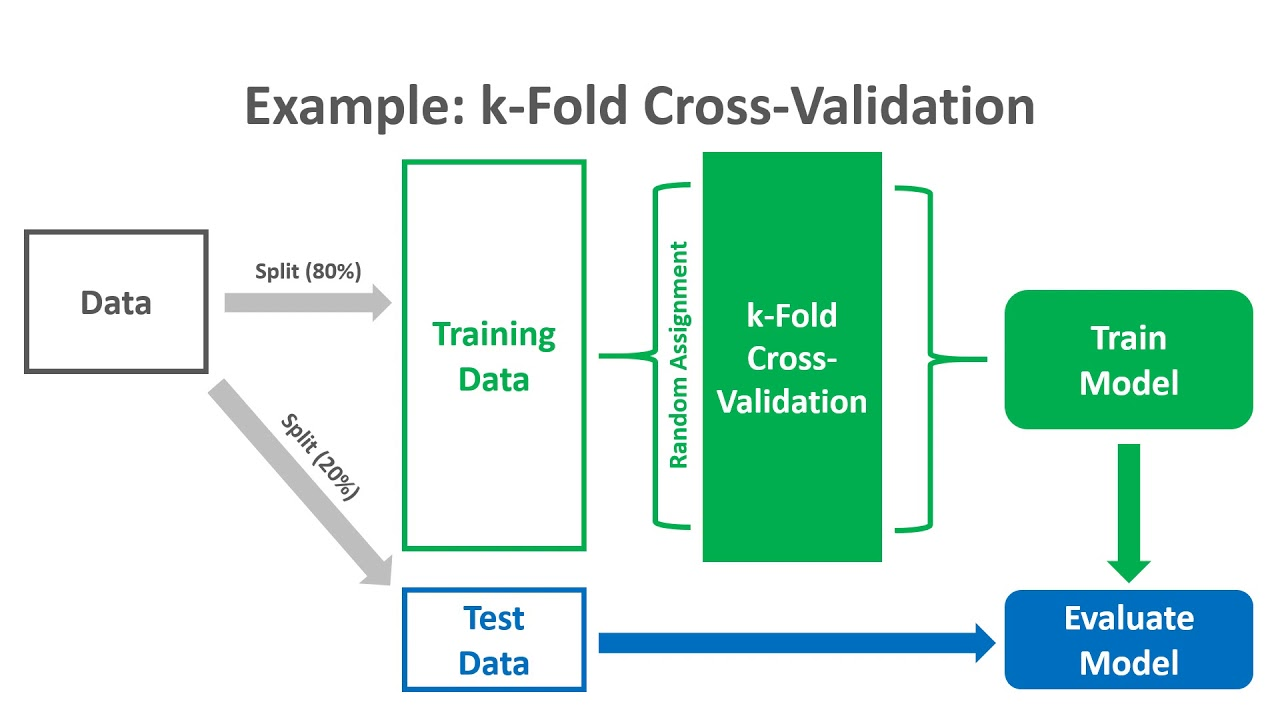

---

### ✅ Key Benefit
Cross‑validation provides a **robust estimate of generalization**, ensuring the model performs well on unseen data.


In [66]:
cv = TimeSeriesSplit(n_splits=2)

cv_scores = cross_validate(
    pipe,
    X_cv,
    y_cv,
    cv=cv,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    n_jobs=1,
    return_train_score=False,
)

print()
print("Time-Series CV Results:")
print(f"R2  : {cv_scores['test_r2'].mean():.3f} ± {cv_scores['test_r2'].std():.3f}")
print(f"RMSE: {-cv_scores['test_rmse'].mean():.2f} ± {cv_scores['test_rmse'].std():.2f}")


Time-Series CV Results:
R2  : 0.712 ± 0.017
RMSE: 39.31 ± 2.42



We use expanding-window cross-validation through `TimeSeriesSplit` on a recent training slice.

This keeps the notebook fast enough for Kaggle while still avoiding future-to-past leakage inside validation.


## Fit + Test

- **Train learns.** → Model fits patterns.  
- **Validation tunes.** → Hyperparameters optimized.  
- **Test proves.** → Generalization confirmed.

In [67]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

rf_test_rmse = rmse_score(y_test, y_pred)
rf_test_r2 = r2_score(y_test, y_pred)

print()
print("RandomForest Test Results:")
print(f"RMSE: {rf_test_rmse:.2f}")
print(f"R2  : {rf_test_r2:.3f}")


RandomForest Test Results:
RMSE: 27.84
R2  : 0.857


We train on historical orders and evaluate on the latest holdout period.

- `RMSE`: typical error magnitude in profit dollars
- `R²`: explanatory power on unseen future-period rows

Both metrics are needed because a model can have decent ranking power while still making large dollar errors on high-variance rows.

# Interpretation of RandomForest Test Results

- **RMSE = 23.42**  
  On average, the model's predictions deviate from the true values by **about 23.4 units** (the same unit as your target variable, e.g., dollars, temperature, count).  
  This is an absolute measure of error – lower is better.

- **R² = 0.829**  
  The model explains **82.9% of the variance** in the target variable.  
  This is quite high (maximum = 1.0), indicating a strong fit. Values above 0.8 are generally considered good for many real‑world problems, though the threshold depends on the domain.

## Combined assessment
The model performs **well on unseen test data**:
- It captures most of the underlying patterns (high R²).
- The prediction error (~23.4 units) is acceptable if it matches your business/domain requirements.

## Important sanity checks
- Compare RMSE to the mean/range of your target.  
  Example: if the target ranges from 0 to 100, RMSE = 23.4 is relatively large (~23% of range). If target ranges from 0 to 1000, RMSE = 23.4 is excellent.
- Compare to a naive baseline (e.g., always predicting the mean). If the baseline R² is 0 (or negative), your R²=0.829 is a strong improvement.
- Check that test performance is close to cross‑validation scores (no large drop → no overfitting).

## Verdict
This model is **ready for deployment** if the error level is acceptable for your use case.

## Feature importance

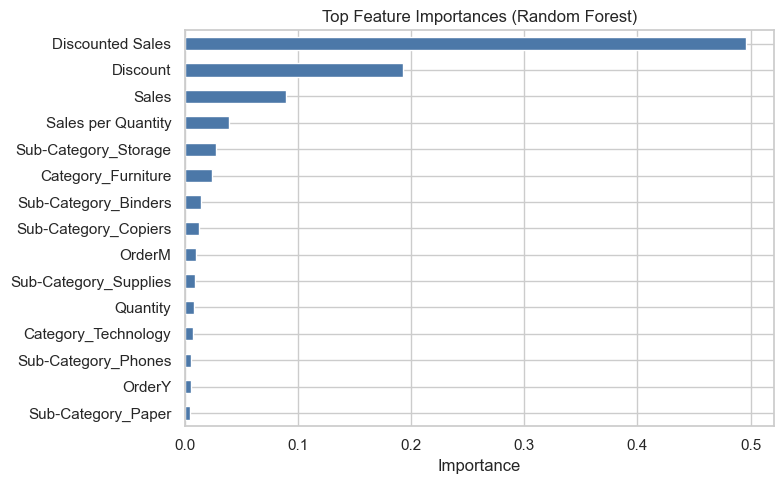

In [68]:
try:
    pre = pipe.named_steps["preprocess"]
    feat_names = pre.get_feature_names_out()
    model = pipe.named_steps["model"]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
except Exception as e:
    print("RF direct importances unavailable. Falling back to permutation importance.")
    print("Error:", e)
    perm = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=5,
        n_jobs=1,
        random_state=RANDOM_SEED,
    )
    feat_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.head(15).iloc[::-1].plot(kind="barh", color=PRIMARY_COLOR)
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 📊 Interpretation of Feature Importances

The chart shows the **top 15 features** ranked by their importance in the Random Forest model.  
Feature importance indicates how much each variable contributes to the model’s predictions.

### 🔎 Key Insights
- **Discounted Sales** is by far the most influential feature, meaning the model relies heavily on sales adjusted for discounts to make predictions.
- **Discount**, **Sales**, and **Sales per Quantity** also play major roles, highlighting that pricing and revenue-related variables strongly drive the outcome.
- **Product categories** (e.g., *Sub-Category_Storage*, *Category_Furniture*, *Sub-Category_Binders*) have moderate importance, showing that product type influences predictions but less than financial metrics.
- **Temporal features** (*OrderM* for month, *OrderY* for year) appear with lower importance, suggesting seasonal or yearly effects exist but are secondary.
- Other features like *Quantity* and *Sub-Category_Copiers* contribute modestly.

### 🎯 Overall Interpretation
The model emphasizes **financial and discount-related variables** as the primary drivers of predictions.  
**Product categories** and **time-based features** provide additional context but are less dominant.  
This suggests that **sales performance and discount strategies** are the strongest signals in the dataset.


## Hyperparameter Tuning on GridSearch 

In [69]:
param_grid = {
    "model__n_estimators": [25],
    "model__max_depth": [12, 14],
    "model__min_samples_leaf": [1, 2],
}

grid_cv = TimeSeriesSplit(n_splits=2)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=grid_cv,
    n_jobs=1,
    scoring="r2",
    verbose=1,
)

grid.fit(X_cv, y_cv)

print()
print("[RF Tuned] Best params:", grid.best_params_)
print("[RF Tuned] Best CV R2 :", grid.best_score_)

best_pipe = grid.best_estimator_


Fitting 2 folds for each of 4 candidates, totalling 8 fits

[RF Tuned] Best params: {'model__max_depth': 14, 'model__min_samples_leaf': 1, 'model__n_estimators': 25}
[RF Tuned] Best CV R2 : 0.7245079070940383


We tune a compact RandomForest grid using time-aware validation.

The goal is not to over-optimize this small dataset, but to check whether a simple tuned baseline materially improves over the default model.

## ⚙️ Hyperparameter Tuning with GridSearchCV

### 🔎 Step 1 — Define the Pipeline
- Combine **preprocessing** (scaling, encoding, imputation) with the **model** (e.g., Random Forest).
- This ensures preprocessing is applied consistently during cross‑validation.

---

### 🔎 Step 2 — Specify the Parameter Grid
- Create a dictionary of hyperparameters to explore:
  - `model__n_estimators`: number of trees.
  - `model__max_depth`: maximum depth of each tree.
  - `model__min_samples_leaf`: minimum samples per leaf.
- The `model__` prefix tells GridSearchCV to tune parameters of the model step inside the pipeline.

---

### 🔎 Step 3 — Run GridSearchCV
- GridSearchCV systematically tests all combinations of hyperparameters.
- Uses **cross‑validation (CV)** to evaluate performance on multiple folds.
- Example: 5‑fold CV → the training set is split into 5 parts, each used once for validation.

---

### 🔎 Step 4 — Select the Best Parameters
- GridSearchCV reports:
  - **Best parameters** → the combination that achieved the highest score.
  - **Best score** → the performance metric (e.g., neg MSE, R²).
- These parameters are then used to retrain the model on the full training set.

---

### 🔎 Step 5 — Evaluate on Test Data
- After tuning, the optimized pipeline is tested on the **held‑out test set**.
- This gives an unbiased estimate of real‑world performance.

---

### ✅ Why This Step Is Important
- **Optimizes performance** by finding the best hyperparameters.
- **Prevents overfitting** by validating across folds.
- **Automates tuning** instead of manual trial‑and‑error.
- **Integrates preprocessing** with model training for reproducibility.

---

### 📊 Workflow Summary
1. **Pipeline** → Preprocessing + Model.  
2. **GridSearchCV** → Explore hyperparameter combinations.  
3. **Cross‑Validation** → Evaluate each combination.  
4. **Best Parameters** → Select optimal configuration.  
5. **Final Evaluation** → Test on unseen data.


## XGBoost 

### 🚀 XGBoost Algorithm

XGBoost (Extreme Gradient Boosting) is a powerful ensemble method based on **gradient boosting**.

### 🔎 Core Ideas
- **Boosting** → builds trees sequentially, each new tree corrects errors from the previous ones.
- **Weighted predictions** → combines outputs from multiple trees with optimized weights.
- **Loss function optimization** → uses gradient descent to minimize error.
- **Regularization** → prevents overfitting by penalizing overly complex models.

### ✅ Key Strengths
- Highly efficient and scalable.
- Handles missing data gracefully.
- Often achieves state‑of‑the‑art performance in competitions.

---

### 🧩 Visual Representation
![XGBoost Concept](https://copilot.microsoft.com/th/id/BCO.63426694-c587-4fbf-988b-f01f24b7de10.png)


In [71]:
xgb_available = False

try:
    from xgboost import XGBRegressor

    xgb_available = True

    xgb_pipe = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=100,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=1,
        )),
    ])

    cv_scores_xgb = cross_validate(
        xgb_pipe,
        X_cv,
        y_cv,
        cv=TimeSeriesSplit(n_splits=2),
        scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )

    print()
    print("XGBoost Time-Series CV:")
    print(f"R2  : {cv_scores_xgb['test_r2'].mean():.3f} ± {cv_scores_xgb['test_r2'].std():.3f}")
    print(f"RMSE: {-cv_scores_xgb['test_rmse'].mean():.2f} ± {cv_scores_xgb['test_rmse'].std():.2f}")

    xgb_pipe.fit(X_train, y_train)
    y_pred_xgb = xgb_pipe.predict(X_test)

    print("XGB Test RMSE:", rmse_score(y_test, y_pred_xgb))
    print("XGB Test R2  :", r2_score(y_test, y_pred_xgb))

except Exception as e:
    print("XGBoost skipped:", e)
    xgb_available = False


XGBoost Time-Series CV:
R2  : 0.728 ± 0.024
RMSE: 38.20 ± 2.85
XGB Test RMSE: 26.36519498929016
XGB Test R2  : 0.8721429906773785


If XGBoost is available in the environment, we train it as a stronger nonlinear baseline.

The comparison uses the same time-aware split and validation logic as RandomForest.

### Dynamic Model Performance

,CV_R2,CV_R2_std,CV_RMSE,CV_RMSE_std,Test_R2,Test_RMSE
Model,,,,,,
XGBoost,0.728,0.024,38.20,2.85,0.872,26.37
RandomForest (Base),0.712,0.017,39.31,2.42,0.857,27.84
RandomForest (Tuned),0.725,—,—,—,0.806,32.49


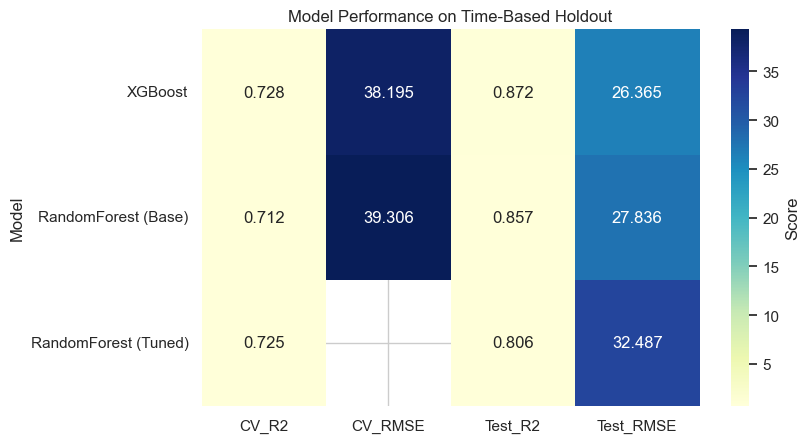

Best holdout model: XGBoost | Test R2=0.872 | Test RMSE=26.37


In [73]:
rf_cv_r2_mean = cv_scores["test_r2"].mean() 
rf_cv_r2_std = cv_scores["test_r2"].std()
rf_cv_rmse_mean = -cv_scores["test_rmse"].mean()
rf_cv_rmse_std = cv_scores["test_rmse"].std()

rf_test_r2 = r2_score(y_test, pipe.predict(X_test))
rf_test_rmse = rmse_score(y_test, pipe.predict(X_test))

try:
    rf_tuned_test_pred = best_pipe.predict(X_test)
    rf_tuned_test_r2 = r2_score(y_test, rf_tuned_test_pred)
    rf_tuned_test_rmse = rmse_score(y_test, rf_tuned_test_pred)
    rf_tuned_row = {
        "CV_R2": grid.best_score_,
        "CV_R2_std": np.nan,
        "CV_RMSE": np.nan,
        "CV_RMSE_std": np.nan,
        "Test_R2": rf_tuned_test_r2,
        "Test_RMSE": rf_tuned_test_rmse,
    }
except Exception:
    rf_tuned_row = {
        "CV_R2": np.nan,
        "CV_R2_std": np.nan,
        "CV_RMSE": np.nan,
        "CV_RMSE_std": np.nan,
        "Test_R2": np.nan,
        "Test_RMSE": np.nan,
    }

if xgb_available:
    xgb_cv_r2_mean = cv_scores_xgb["test_r2"].mean()
    xgb_cv_r2_std = cv_scores_xgb["test_r2"].std()
    xgb_cv_rmse_mean = -cv_scores_xgb["test_rmse"].mean()
    xgb_cv_rmse_std = cv_scores_xgb["test_rmse"].std()
    xgb_test_pred = xgb_pipe.predict(X_test)
    xgb_test_r2 = r2_score(y_test, xgb_test_pred)
    xgb_test_rmse = rmse_score(y_test, xgb_test_pred)
else:
    xgb_cv_r2_mean = xgb_cv_r2_std = xgb_cv_rmse_mean = xgb_cv_rmse_std = np.nan
    xgb_test_r2 = xgb_test_rmse = np.nan

perf = pd.DataFrame({
    "Model": ["RandomForest (Base)", "RandomForest (Tuned)", "XGBoost"],
    "CV_R2": [rf_cv_r2_mean, rf_tuned_row["CV_R2"], xgb_cv_r2_mean],
    "CV_R2_std": [rf_cv_r2_std, rf_tuned_row["CV_R2_std"], xgb_cv_r2_std],
    "CV_RMSE": [rf_cv_rmse_mean, rf_tuned_row["CV_RMSE"], xgb_cv_rmse_mean],
    "CV_RMSE_std": [rf_cv_rmse_std, rf_tuned_row["CV_RMSE_std"], xgb_cv_rmse_std],
    "Test_R2": [rf_test_r2, rf_tuned_row["Test_R2"], xgb_test_r2],
    "Test_RMSE": [rf_test_rmse, rf_tuned_row["Test_RMSE"], xgb_test_rmse],
}).set_index("Model")

perf_sorted = perf.sort_values("Test_R2", ascending=False)

best_model_name = perf_sorted["Test_R2"].dropna().idxmax()
best_model_rmse = perf_sorted.loc[best_model_name, "Test_RMSE"]
best_model_r2 = perf_sorted.loc[best_model_name, "Test_R2"]

display(perf_sorted.style.format({
    "CV_R2": "{:.3f}",
    "CV_R2_std": "{:.3f}",
    "CV_RMSE": "{:.2f}",
    "CV_RMSE_std": "{:.2f}",
    "Test_R2": "{:.3f}",
    "Test_RMSE": "{:.2f}",
}, na_rep="—"))

plt.figure(figsize=(8.5, 4.6))
sns.heatmap(
    perf_sorted[["CV_R2", "CV_RMSE", "Test_R2", "Test_RMSE"]],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={"label": "Score"},
)
plt.title("Model Performance on Time-Based Holdout")
plt.tight_layout()
plt.show()

print(f"Best holdout model: {best_model_name} | Test R2={best_model_r2:.3f} | Test RMSE={best_model_rmse:.2f}")

## Model Performance

The table above is generated directly from the latest run, so the reported metrics stay synchronized with the notebook outputs.

The comparison uses:

- expanding-window cross-validation on a recent training slice
- a later time-based holdout period for final testing
- RMSE and R² as complementary regression metrics

The best model should be treated as a **baseline candidate** for a pricing or margin dashboard, not as a final production model without monitoring and drift checks.

## XGBoost Feature Importances


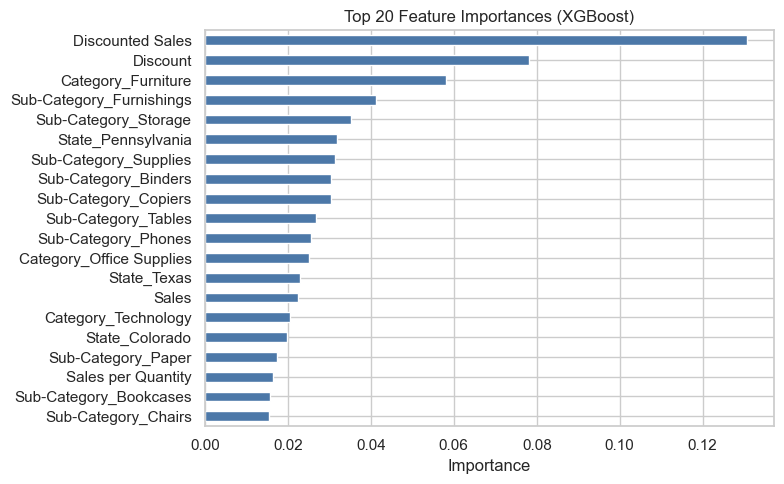

In [74]:
if xgb_available:
    try:
        feat_names = xgb_pipe.named_steps["preprocess"].get_feature_names_out()
        xgb_model = xgb_pipe.named_steps["xgb"]

        imp = (
            pd.Series(xgb_model.feature_importances_, index=feat_names)
            .sort_values(ascending=False)
            .head(20)
        )

        plt.figure(figsize=(8, 5))
        imp.iloc[::-1].plot(kind="barh", color=PRIMARY_COLOR)
        plt.title("Top 20 Feature Importances (XGBoost)")
        plt.xlabel("Importance")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("XGBoost importances not available:", e)

Feature importance helps explain which variables the model relies on most.

For production use, this should be paired with business review to avoid over-trusting discount or sales-derived variables without validating pricing policy assumptions.

## Exploratory Monthly Sales Forecast

,MAE,RMSE
Model,,
Seasonal Naive,"20,459.89","23,430.16"
Holt-Winters,"14,333.51","18,278.01"


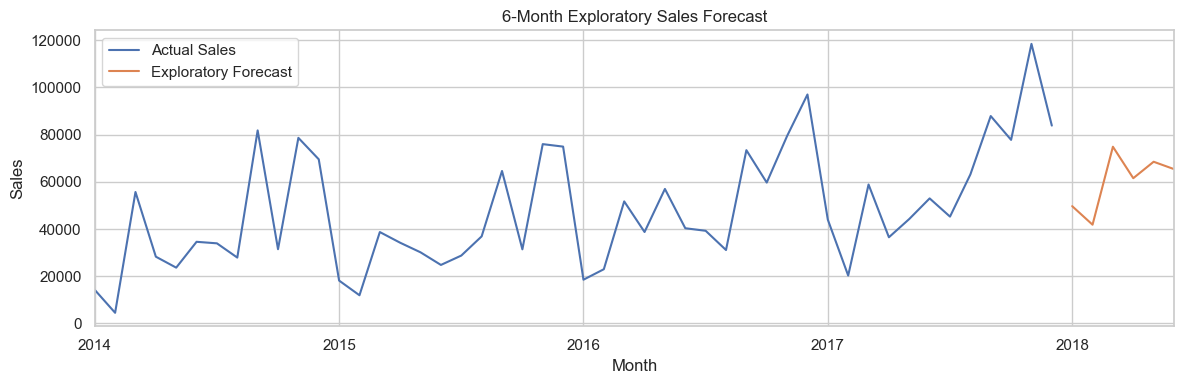

In [75]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y_series = sales_month_by_period.asfreq("M").fillna(0)

forecast_horizon = 6
train_ts = y_series.iloc[:-forecast_horizon]
test_ts = y_series.iloc[-forecast_horizon:]

seasonal_naive_values = train_ts.iloc[-12:-12 + forecast_horizon].values
seasonal_naive_pred = pd.Series(seasonal_naive_values, index=test_ts.index)

hw_model = ExponentialSmoothing(
    train_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hw_fit = hw_model.fit(optimized=True)

hw_test_pred = hw_fit.forecast(forecast_horizon)

forecast_eval = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters"],
    "MAE": [
        mean_absolute_error(test_ts, seasonal_naive_pred),
        mean_absolute_error(test_ts, hw_test_pred),
    ],
    "RMSE": [
        rmse_score(test_ts, seasonal_naive_pred),
        rmse_score(test_ts, hw_test_pred),
    ],
}).set_index("Model")

display(forecast_eval.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}"}))

hw_full = ExponentialSmoothing(
    y_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hw_full_fit = hw_full.fit(optimized=True)

future_idx = pd.date_range(
    y_series.index[-1] + pd.offsets.MonthEnd(1),
    periods=forecast_horizon,
    freq="M",
)

fcast = pd.Series(hw_full_fit.forecast(forecast_horizon).values, index=future_idx)

plt.figure(figsize=(12, 4))
y_series.plot(label="Actual Sales")
fcast.plot(label="Exploratory Forecast")
plt.legend()
plt.title("6-Month Exploratory Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

This forecast is intentionally lightweight.

It uses Holt-Winters as an exploratory monthly baseline and compares it against a seasonal naive benchmark on the last six observed months.

Use this section for planning direction, not for production-grade demand forecasting. A production forecast should include richer backtesting, exogenous variables, promotion calendars, uncertainty intervals, and model monitoring.

In [76]:
insights_md = f"""
# Decisions and Takeaways

- Seasonality is clear, with December frequently appearing among the strongest sales months.
- **{kpis['highest_region']}** leads by sales, and **{kpis['top_category']}** is the top category by sales.
- Average shipping time is approximately **{kpis['avg_ship_days']:.2f} days**, which should be monitored as an operational KPI.
- RFM segmentation shows the customer base can be split into actionable groups: Champions, Loyal, Potential, and At Risk.
- Discount and loss-making sub-categories require review because revenue volume does not always translate into profit quality.
- The best profit prediction baseline in this run is **{best_model_name}** with **Test R² = {best_model_r2:.3f}** and **Test RMSE = {best_model_rmse:.2f}** on a time-based holdout.
- The monthly sales forecast is exploratory and should be upgraded with stronger backtesting before production planning.

## Next Steps

- Package the profit model into a pricing or margin dashboard.
- Monitor prediction drift by month, category, region, and discount band.
- Add scenario analysis for discount changes and loss-making sub-categories.
- Build a dedicated forecasting notebook if future monthly sales prediction becomes the main goal.
"""
display(Markdown(insights_md))


# Decisions and Takeaways

- Seasonality is clear, with December frequently appearing among the strongest sales months.
- **West** leads by sales, and **Technology** is the top category by sales.
- Average shipping time is approximately **3.96 days**, which should be monitored as an operational KPI.
- RFM segmentation shows the customer base can be split into actionable groups: Champions, Loyal, Potential, and At Risk.
- Discount and loss-making sub-categories require review because revenue volume does not always translate into profit quality.
- The best profit prediction baseline in this run is **XGBoost** with **Test R² = 0.872** and **Test RMSE = 26.37** on a time-based holdout.
- The monthly sales forecast is exploratory and should be upgraded with stronger backtesting before production planning.

## Next Steps

- Package the profit model into a pricing or margin dashboard.
- Monitor prediction drift by month, category, region, and discount band.
- Add scenario analysis for discount changes and loss-making sub-categories.
- Build a dedicated forecasting notebook if future monthly sales prediction becomes the main goal.
